In [1]:
from transformers import AutoImageProcessor


In [1]:
import pandas as pd

In [2]:
t = pd.read_csv("ml_ozon_сounterfeit_test_new_features0.csv")

In [12]:
t.loc[t['SellerID'] == 2898]['seller_time_alive'].max()

np.float64(347.0)

In [11]:
t.loc[t['ItemID'] == 523597]

,id,brand_name,description,name_rus,CommercialTypeName4,rating_1_count,rating_2_count,rating_3_count,rating_4_count,rating_5_count,...,ExemplarReturnedCountTotal30,ExemplarReturnedCountTotal90,ExemplarReturnedValueTotal7,ExemplarReturnedValueTotal30,ExemplarReturnedValueTotal90,ItemVarietyCount,ItemAvailableCount,seller_time_alive,ItemID,SellerID
3100,3100,Sony,Станьте ближе к игре благодаря трем передовым ...,"Игра FC 24 (PlayStation 5, Русская версия)",Видеоигра Sony,2.0,0.0,0.0,0.0,3.0,...,43.0,118.0,1023.632305,1184.870667,1282.265465,10.0,10.0,299.0,523597,2898


In [ ]:
import pandas as pd
import numpy as np
# from typing import Tuple, Dict, List

# def map_global_stats(
#     train_df: pd.DataFrame,
#     val_df: pd.DataFrame,
#     test_df: pd.DataFrame,
#     cols: List[str],
#     target: str,
#     alpha: float = 30.0,
#     eps: float = 1e-12
# ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict[str,dict]]:
#     """
#     Compute global/category stats on train_df and map them to train/val/test.

#     Parameters
#     ----------
#     train_df, val_df, test_df : pd.DataFrame
#       Input DataFrames. train_df must contain `target` and each column in `cols`.
#     cols : list of str
#       Categorical columns to encode (e.g., ['CommercialTypeName4']).
#     target : str
#       Binary target column name in train_df (0/1).
#     alpha : float
#       Smoothing strength for TE.
#     eps : float
#       Small epsilon to avoid division by zero for rates.

#     Returns
#     -------
#     train_mapped, val_mapped, test_mapped, artifacts
#       Copies of the input DataFrames with new columns added, and artifacts per col.
#     """

#     # basic checks
#     if target not in train_df.columns:
#         raise ValueError(f"Target column '{target}' not found in train_df")
#     # require binary-ish target
#     unique_vals = pd.Series(train_df[target].dropna().unique())
#     if not set(unique_vals).issubset({0,1}):
#         raise ValueError("Target should be binary 0/1 in train_df")

#     train = train_df.copy()
#     val = val_df.copy()
#     test = test_df.copy()

#     artifacts = {}

#     global_mean = float(train[target].mean())

#     for col in cols:
#         if col not in train.columns:
#             raise ValueError(f"Column '{col}' not found in train_df")

#         # compute stats on train
#         cat_stats = train.groupby(col)[target].agg(['sum','count']).rename(columns={'sum':'pos','count':'total'}).reset_index()

#         # smoothed target-encode (train-global)
#         cat_stats['te_smoothed'] = (cat_stats['pos'] + alpha * global_mean) / (cat_stats['total'] + alpha)

#         # create maps
#         full_map = dict(zip(cat_stats[col], cat_stats['te_smoothed']))
#         count_map = dict(zip(cat_stats[col], cat_stats['total']))
#         pos_map = dict(zip(cat_stats[col], cat_stats['pos']))

#         # helper mapper
#         def _map_to(df: pd.DataFrame):
#             # copy to avoid side-effects
#             df = df.copy()
#             # map TE, unseen -> global_mean
#             df[f'{col}_te'] = df[col].map(full_map).fillna(global_mean).astype(float)
#             # counts/pos (unseen -> 0)
#             df[f'{col}_total'] = df[col].map(count_map).fillna(0).astype(float)
#             df[f'{col}_pos'] = df[col].map(pos_map).fillna(0).astype(float)
#             # rates & flags
#             df[f'{col}_pos_rate'] = df[f'{col}_pos'] / (df[f'{col}_total'] + eps)
#             df[f'{col}_no_pos'] = (df[f'{col}_pos'] == 0).astype(int)
#             # unseen flag: True when category not in train's observed categories OR value is NaN
#             seen_cats = set(count_map.keys())
#             df[f'{col}_unseen'] = (~df[col].isin(seen_cats) | df[col].isna()).astype(int)
#             return df

#         # map to all splits
#         train = _map_to(train)
#         val = _map_to(val)
#         test = _map_to(test)G

#         # store artifacts
#         artifacts[col] = {
#             'full_map': full_map,
#             'count_map': count_map,
#             'pos_map': pos_map,
#             'global_mean': global_mean,
#             'cat_stats': cat_stats
#         }

#     return train, val, test, artifacts



In [1]:
# Categorical shift checks
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import math

def topk_prop_table(a, b, col, topk=20):
    a = a[col].fillna("<unk>").astype(str)
    b = b[col].fillna("<unk>").astype(str)
    top = pd.concat([a,b]).value_counts().index[:topk]
    a_counts = a[a.isin(top)].value_counts().reindex(top, fill_value=0)
    b_counts = b[b.isin(top)].value_counts().reindex(top, fill_value=0)
    df = pd.DataFrame({"category": top, "prop_a": a_counts / a_counts.sum(), "prop_b": b_counts / b_counts.sum(),
                       "count_a": a_counts.values, "count_b": b_counts.values})
    df["abs_diff"] = (df["prop_b"] - df["prop_a"]).abs()
    return df.sort_values("abs_diff", ascending=False)

# Smoothed KL divergence (add-alpha)
def kl_divergence_smoothed(a_counts, b_counts, alpha=1.0):
    # a_counts, b_counts are aligned arrays (same categories)
    a = np.array(a_counts) + alpha
    b = np.array(b_counts) + alpha
    pa = a / a.sum()
    pb = b / b.sum()
    return np.sum(pa * np.log(pa / pb + 1e-12))

# Permutation test for difference in proportion for a single category
def perm_test_prop(a, b, category_value, n_perm=10000, seed=0):
    rng = np.random.RandomState(seed)
    sa = (a == category_value).astype(int)
    sb = (b == category_value).astype(int)
    obs = sb.mean() - sa.mean()
    pooled = np.concatenate([sa, sb])
    n_a = len(sa)
    vals = []
    for _ in range(n_perm):
        rng.shuffle(pooled)
        vals.append(pooled[n_a:].mean() - pooled[:n_a].mean())
    p = (np.sum(np.abs(vals) >= np.abs(obs)) + 1) / (n_perm + 1)
    return obs, p

# Example usage:
# report = topk_prop_table(df_val, df_test, col="brand_name", topk=30)
# report.head(20)
# kl = kl_divergence_smoothed(report["count_a"], report["count_b"], alpha=0.5)
# obs, p = perm_test_prop(df_val["brand_name"].fillna("<unk>").astype(str),
#                         df_test["brand_name"].fillna("<unk>").astype(str),
#                         category_value="SOME_BRAND")


In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import KFold

# # ---------- helpers ----------
# def choose_top_by_coverage(counts_df, coverage=0.95,category = None):
#     # counts_df: DataFrame with columns ['category','count']
#     df = counts_df.sort_values("count", ascending=False).reset_index(drop=True)
#     df['cumcount'] = df['count'].cumsum()
#     df['cumprop'] = df['cumcount'] / df['count'].sum()
#     # include the row that first exceeds coverage
#     cutoff_idx = df[df['cumprop'] <= coverage].index.max()
#     if np.isnan(cutoff_idx):
#         cutoff_idx = 0
#     top = df.loc[:cutoff_idx, category].tolist()
#     return top, df

# def build_mapper(top_categories):
#     top_set = set(top_categories)
#     def mapper(x):
#         if pd.isna(x): return "<unk>"
#         s = str(x).strip()
#         return s if s in top_set else "__OTHER__"
#     return mapper

# # ---------- frequency map ----------
# def freq_map_from_train(train, col):
#     counts = train[col].fillna("<unk>").astype(str).value_counts()
#     total = counts.sum()
#     freq_map = (counts / total).to_dict()
#     return freq_map, counts.to_frame("count").reset_index().rename(columns={"index":col})

# # ---------- K-fold smoothed target encoding (out-of-fold for train) ----------
# def target_encode_kfold(train_df, col, target_col="y", n_splits=5, smoothing=20, seed=0):
#     """
#     Returns:
#       - enc_map_full: mapping category -> smoothed mean computed on full train
#       - oof_array: out-of-fold encoded values for train_df (same order)
#       - global_mean
#     Notes:
#       - train_df[col] should already have mapped rare categories (e.g. __OTHER__)
#     """
#     X = train_df.copy()
#     global_mean = X[target_col].mean()
#     oof = np.zeros(len(X), dtype=float)
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
#     for tr_idx, val_idx in kf.split(X):
#         tr = X.iloc[tr_idx]
#         val = X.iloc[val_idx]
#         stats = tr.groupby(col)[target_col].agg(['sum','count'])
#         # smoothing: (sum + m * global) / (count + m)
#         stats['smooth'] = (stats['sum'] + smoothing * global_mean) / (stats['count'] + smoothing)
#         mapping = stats['smooth'].to_dict()
#         oof[val_idx] = val[col].map(mapping).fillna(global_mean).values

#     # final enc map on full train
#     stats_full = X.groupby(col)[target_col].agg(['sum','count'])
#     stats_full['smooth'] = (stats_full['sum'] + smoothing * global_mean) / (stats_full['count'] + smoothing)
#     enc_map_full = stats_full['smooth'].to_dict()
#     # Ensure __OTHER__ exists in map (compute from train rows mapped to __OTHER__)
#     if "__OTHER__" not in enc_map_full:
#         other_mean = X.loc[X[col]=="__OTHER__", target_col].mean()
#         enc_map_full["__OTHER__"] = other_mean if not np.isnan(other_mean) else global_mean

#     return enc_map_full, oof, global_mean

# # ---------- apply to train/test ----------
# def prepare_commercial_col(train, test, col="CommercialTypeName4",
#                            coverage=0.95, min_count=None, smoothing=50, target_col="is_fake"):
#     # compute train counts
#     freq_map, counts_df = freq_map_from_train(train, col)
#     counts_df = counts_df.rename(columns={col: "category"})
#     # choose top categories
#     if min_count is not None:
#         top_categories = counts_df[counts_df['count'] >= min_count]['category'].tolist()
#     else:
#         top_categories, counts_df = choose_top_by_coverage(counts_df.rename(columns={"category":col}), coverage=coverage,category = col)
#     mapper = build_mapper(top_categories)

#     # map train/test
#     train[col + "_mapped"] = train[col].map(lambda x: mapper(x)).fillna("<unk>")
#     test[col + "_mapped"] = test[col].map(lambda x: mapper(x)).fillna("<unk>")

#     # frequency features (train freq map; unseen -> 0)
#     total = sum(counts_df['count']) if 'count' in counts_df.columns else sum(freq_map.values())
#     train[col + "_freq"] = train[col].fillna("<unk>").astype(str).map(lambda x: freq_map.get(str(x), 0))
#     test[col + "_freq"]  = test[col].fillna("<unk>").astype(str).map(lambda x: freq_map.get(str(x), 0)).fillna(0.0)

#     # count feature (train counts)
#     train_counts = counts_df.set_index(col)['count'].to_dict() if 'count' in counts_df.columns else {}
#     train[col + "_count"] = train[col].fillna("<unk>").astype(str).map(lambda x: train_counts.get(str(x), 0)).fillna(0).astype(int)
#     test[col + "_count"]  = test[col].fillna("<unk>").astype(str).map(lambda x: train_counts.get(str(x), 0)).fillna(0).astype(int)

#     # unseen flag for test (1 if test value not in train top set)
#     train[col + "_is_top"] = train[col + "_mapped"].apply(lambda x: 1 if (x != "__OTHER__" and x != "<unk>") else 0)
#     test[col + "_is_top"]  = test[col + "_mapped"].apply(lambda x: 1 if (x != "__OTHER__" and x != "<unk>") else 0)
#     test[col + "_is_unseen"] = ~test[col].isin(train[col].astype(str).unique())

#     # target encoding via K-fold (train oof + full enc_map for test)
#     enc_map_full, oof, global_mean = target_encode_kfold(train.assign(**{col: train[col + "_mapped"]}), col + "_mapped",
#                                                          target_col=target_col, n_splits=5, smoothing=smoothing)
#     train[col + "_te"] = oof
#     # for test, map and fall back to enc_map_full['__OTHER__'] or global_mean
#     test[col + "_te"] = test[col + "_mapped"].map(lambda x: enc_map_full.get(x, enc_map_full.get("__OTHER__", global_mean)))
#     return train, test, counts_df, top_categories

# # ---------- usage ----------
# # train = pd.read_csv("train.csv")   # must contain target column 'is_fake'
# # test  = pd.read_csv("test.csv")
# # train_prep, test_prep, counts_df, top_categories = prepare_commercial_col(train, test,
# #                                                                           col="CommercialTypeName4",
# #                                                                           coverage=0.95,
# #                                                                           min_count=None,
# #                                                                           smoothing=50,
# #                                                                           target_col="is_fake")


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold

# ---------- helpers ----------
def choose_top_by_coverage(counts_df, coverage=0.95,category = None):
    # counts_df: DataFrame with columns ['category','count']
    df = counts_df.sort_values("count", ascending=False).reset_index(drop=True)
    df['cumcount'] = df['count'].cumsum()
    df['cumprop'] = df['cumcount'] / df['count'].sum()
    # include the row that first exceeds coverage
    cutoff_idx = df[df['cumprop'] <= coverage].index.max()
    if np.isnan(cutoff_idx):
        cutoff_idx = 0
    top = df.loc[:cutoff_idx, category].tolist()
    return top, df

def build_mapper(top_categories):
    top_set = set(top_categories)
    def mapper(x):
        if pd.isna(x): return "<unk>"
        s = str(x).strip()
        return s if s in top_set else "<rare>"
    return mapper

# ---------- frequency map ----------
def freq_map_from_train(train, col):
    counts = train[col].fillna("<unk>").astype(str).value_counts()
    total = counts.sum()
    freq_map = (counts / total).to_dict()
    return freq_map, counts.to_frame("count").reset_index().rename(columns={"index":col})

# ---------- K-fold smoothed target encoding (out-of-fold for train) ----------
def target_encode_kfold(train_df, col, target_col="y", n_splits=5, smoothing=20, seed=0):
    """
    Returns:
      - enc_map_full: mapping category -> smoothed mean computed on full train
      - oof_array: out-of-fold encoded values for train_df (same order)
      - global_mean
    Notes:
      - train_df[col] should already have mapped rare categories (e.g. __OTHER__)
    """
    X = train_df.copy()
    global_mean = X[target_col].mean()
    oof = np.zeros(len(X), dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in kf.split(X):
        tr = X.iloc[tr_idx]
        val = X.iloc[val_idx]
        stats = tr.groupby(col)[target_col].agg(['sum','count'])
        # smoothing: (sum + m * global) / (count + m)
        stats['smooth'] = (stats['sum'] + smoothing * global_mean) / (stats['count'] + smoothing)
        mapping = stats['smooth'].to_dict()
        oof[val_idx] = val[col].map(mapping).fillna(global_mean).values

    # final enc map on full train
    stats_full = X.groupby(col)[target_col].agg(['sum','count'])
    stats_full['smooth'] = (stats_full['sum'] + smoothing * global_mean) / (stats_full['count'] + smoothing)
    enc_map_full = stats_full['smooth'].to_dict()
    # Ensure __OTHER__ exists in map (compute from train rows mapped to __OTHER__)
    if "<rare>" not in enc_map_full:
        other_mean = X.loc[X[col]=="<rare>", target_col].mean()
        enc_map_full["<rare>"] = other_mean if not np.isnan(other_mean) else global_mean

    return enc_map_full, oof, global_mean

# ---------- apply to train/test ----------
def prepare_commercial_col(train, test, col="CommercialTypeName4",
                           coverage=0.95, min_count=None, smoothing=50, target_col="is_fake"):
    # compute train counts
    freq_map, counts_df = freq_map_from_train(train, col)
    counts_df = counts_df.rename(columns={col: "category"})
    # choose top categories
    if min_count is not None:
        top_categories = counts_df[counts_df['count'] >= min_count]['category'].tolist()
    else:
        top_categories, counts_df = choose_top_by_coverage(counts_df.rename(columns={"category":col}), coverage=coverage,category = col)
    mapper = build_mapper(top_categories)

    # map train/test
    train[col + "_mapped"] = train[col].map(lambda x: mapper(x)).fillna("<unk>")
    test[col + "_mapped"] = test[col].map(lambda x: mapper(x)).fillna("<unk>")

    # frequency features (train freq map; unseen -> 0)
    total = sum(counts_df['count']) if 'count' in counts_df.columns else sum(freq_map.values())
    train[col + "_freq"] = train[col].fillna("<unk>").astype(str).map(lambda x: freq_map.get(str(x), 0))
    test[col + "_freq"]  = test[col].fillna("<unk>").astype(str).map(lambda x: freq_map.get(str(x), 0)).fillna(0.0)

    # count feature (train counts)
    train_counts = counts_df.set_index(col)['count'].to_dict() if 'count' in counts_df.columns else {}
    train[col + "_count"] = train[col].fillna("<unk>").astype(str).map(lambda x: train_counts.get(str(x), 0)).fillna(0).astype(int)
    test[col + "_count"]  = test[col].fillna("<unk>").astype(str).map(lambda x: train_counts.get(str(x), 0)).fillna(0).astype(int)

    # unseen flag for test (1 if test value not in train top set)
    train[col + "_is_top"] = train[col + "_mapped"].apply(lambda x: 1 if (x != "<rare>" and x != "<unk>") else 0)
    test[col + "_is_top"]  = test[col + "_mapped"].apply(lambda x: 1 if (x != "<rare>" and x != "<unk>") else 0)
    test[col + "_is_unseen"] = ~test[col].isin(train[col].astype(str).unique())

    # target encoding via K-fold (train oof + full enc_map for test)
    enc_map_full, oof, global_mean = target_encode_kfold(train.assign(**{col: train[col + "_mapped"]}), col + "_mapped",
                                                         target_col=target_col, n_splits=5, smoothing=smoothing)
    train[col + "_te"] = oof
    # for test, map and fall back to enc_map_full['__OTHER__'] or global_mean
    test[col + "_te"] = test[col + "_mapped"].map(lambda x: enc_map_full.get(x, enc_map_full.get("<rare>", global_mean)))
    return train, test, counts_df, top_categories

# ---------- usage ----------
# train = pd.read_csv("train.csv")   # must contain target column 'is_fake'
# test  = pd.read_csv("test.csv")
# train_prep, test_prep, counts_df, top_categories = prepare_commercial_col(train, test,
#                                                                           col="CommercialTypeName4",
#                                                                           coverage=0.95,
#                                                                           min_count=None,
#                                                                           smoothing=50,
#                                                                           target_col="is_fake")


In [2]:
df_train = pd.read_csv("ml_ozon_counterfeit_train.csv")
df_test = pd.read_csv("ml_ozon_counterfeit_test.csv")
train = df_train
test = df_test


In [3]:
train_prep_seller, test_prep_seller, counts_df_seller, top_categories_seller = prepare_commercial_col(train, test,
                                                                          col="SellerID",
                                                                          coverage=0.85,
                                                                          min_count=None,
                                                                          smoothing=50,
                                                                          target_col="resolution")

In [149]:
df_train = pd.concat([train_df,val_df])

In [151]:
train_prep, test_prep, counts_df, top_categories = prepare_commercial_col(df_train, test_df,
                                                                          col="CommercialTypeName4",
                                                                          coverage=0.95,
                                                                          min_count=None,
                                                                          smoothing=50,
                                                                          target_col="resolution")

In [152]:
# train = df_train
# test = df_test
train_prep_brand, test_prep_brand, counts_df_brand, top_categories_brand = prepare_commercial_col(df_train, test_df,
                                                                          col="brand_name",
                                                                          coverage=0.95,
                                                                          min_count=None,
                                                                          smoothing=50,
                                                                          target_col="resolution")

In [153]:
train_prep.loc[train_prep['CommercialTypeName4_mapped'] == '<rare>','CommercialTypeName4'] = "<rare>" + train_prep.loc[train_prep['CommercialTypeName4_mapped'] == '<rare>','CommercialTypeName4']


In [154]:
test_prep.loc[test_prep['CommercialTypeName4_mapped'] == '<rare>','CommercialTypeName4'] = "<rare>" + test_prep.loc[test_prep['CommercialTypeName4_mapped'] == '<rare>','CommercialTypeName4']

In [155]:
train_prep_brand.loc[train_prep_brand['brand_name_mapped'] == '<rare>','brand_name'] = "<rare>" + train_prep_brand.loc[train_prep_brand['brand_name_mapped'] == '<rare>','brand_name']
test_prep_brand.loc[test_prep_brand['brand_name_mapped'] == '<rare>','brand_name'] = "<rare>" + test_prep_brand.loc[test_prep_brand['brand_name_mapped'] == '<rare>','brand_name']

In [ ]:
import pickle
X_val_split = pickle.load(open("X_val_split.pkl",'rb'))
X_train_split = pickle.load(open("X_train_split.pkl",'rb'))
X_test = pickle.load(open("X_test.pkl",'rb'))

In [ ]:
# train_prep_split = train_prep.set_index('id').loc[X_train_split.index]

In [ ]:
# val_prep = train_prep.set_index('id').loc[X_val_split.index]
# test_prep = test_prep.set_index('id').loc[X_test.index]

In [ ]:
# train_df = pd.read_csv("../counterfeit_multimodal/data/train_m_trim.csv")
# val_df = pd.read_csv("../counterfeit_multimodal/data/val_m_trim.csv")
# test_df = pd.read_csv("../counterfeit_multimodal/data/test_m_trim.csv")

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold

# ---------- helpers ----------
def choose_top_by_coverage(counts_df, coverage=0.95,category = None):
    # counts_df: DataFrame with columns ['category','count']
    df = counts_df.sort_values("count", ascending=False).reset_index(drop=True)
    df['cumcount'] = df['count'].cumsum()
    df['cumprop'] = df['cumcount'] / df['count'].sum()
    # include the row that first exceeds coverage
    cutoff_idx = df[df['cumprop'] <= coverage].index.max()
    if np.isnan(cutoff_idx):
        cutoff_idx = 0
    top = df.loc[:cutoff_idx, category].tolist()
    return top, df

def build_mapper(top_categories):
    top_set = set(top_categories)
    def mapper(x):
        if pd.isna(x): return "<unk>"
        s = str(x).strip()
        return s if s in top_set else "<rare>"
    return mapper

# ---------- frequency map ----------
def freq_map_from_train(train, col):
    counts = train[col].fillna("<unk>").astype(str).value_counts()
    total = counts.sum()
    freq_map = (counts / total).to_dict()
    return freq_map, counts.to_frame("count").reset_index().rename(columns={"index":col})

# ---------- K-fold smoothed target encoding (out-of-fold for train) ----------
def target_encode_kfold(train_df, col, target_col="y", n_splits=5, smoothing=20, seed=0):
    """
    Returns:
      - enc_map_full: mapping category -> smoothed mean computed on full train
      - oof_array: out-of-fold encoded values for train_df (same order)
      - global_mean
    Notes:
      - train_df[col] should already have mapped rare categories (e.g. __OTHER__)
    """
    X = train_df.copy()
    global_mean = X[target_col].mean()
    oof = np.zeros(len(X), dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in kf.split(X):
        tr = X.iloc[tr_idx]
        val = X.iloc[val_idx]
        stats = tr.groupby(col)[target_col].agg(['sum','count'])
        # smoothing: (sum + m * global) / (count + m)
        stats['smooth'] = (stats['sum'] + smoothing * global_mean) / (stats['count'] + smoothing)
        mapping = stats['smooth'].to_dict()
        oof[val_idx] = val[col].map(mapping).fillna(global_mean).values

    # final enc map on full train
    stats_full = X.groupby(col)[target_col].agg(['sum','count'])
    stats_full['smooth'] = (stats_full['sum'] + smoothing * global_mean) / (stats_full['count'] + smoothing)
    enc_map_full = stats_full['smooth'].to_dict()
    # Ensure __OTHER__ exists in map (compute from train rows mapped to __OTHER__)
    if "<rare>" not in enc_map_full:
        other_mean = X.loc[X[col]=="<rare>", target_col].mean()
        enc_map_full["<rare>"] = other_mean if not np.isnan(other_mean) else global_mean

    return enc_map_full, oof, global_mean

# ---------- apply to train/test ----------
def prepare_commercial_col(train, test, col="CommercialTypeName4",
                           coverage=0.95, min_count=None, smoothing=50, target_col="is_fake"):
    # compute train counts
    freq_map, counts_df = freq_map_from_train(train, col)
    counts_df = counts_df.rename(columns={col: "category"})
    # choose top categories
    if min_count is not None:
        top_categories = counts_df[counts_df['count'] >= min_count]['category'].tolist()
    else:
        top_categories, counts_df = choose_top_by_coverage(counts_df.rename(columns={"category":col}), coverage=coverage,category = col)
    mapper = build_mapper(top_categories)

    # map train/test
    train[col + "_mapped"] = train[col].map(lambda x: mapper(x)).fillna("<unk>")
    test[col + "_mapped"] = test[col].map(lambda x: mapper(x)).fillna("<unk>")

    # frequency features (train freq map; unseen -> 0)
    total = sum(counts_df['count']) if 'count' in counts_df.columns else sum(freq_map.values())
    train[col + "_freq"] = train[col].fillna("<unk>").astype(str).map(lambda x: freq_map.get(str(x), 0))
    test[col + "_freq"]  = test[col].fillna("<unk>").astype(str).map(lambda x: freq_map.get(str(x), 0)).fillna(0.0)

    # count feature (train counts)
    train_counts = counts_df.set_index(col)['count'].to_dict() if 'count' in counts_df.columns else {}
    train[col + "_count"] = train[col].fillna("<unk>").astype(str).map(lambda x: train_counts.get(str(x), 0)).fillna(0).astype(int)
    test[col + "_count"]  = test[col].fillna("<unk>").astype(str).map(lambda x: train_counts.get(str(x), 0)).fillna(0).astype(int)

    # unseen flag for test (1 if test value not in train top set)
    train[col + "_is_top"] = train[col + "_mapped"].apply(lambda x: 1 if (x != "<rare>" and x != "<unk>") else 0)
    test[col + "_is_top"]  = test[col + "_mapped"].apply(lambda x: 1 if (x != "<rare>" and x != "<unk>") else 0)
    test[col + "_is_unseen"] = ~test[col].isin(train[col].astype(str).unique())

    # target encoding via K-fold (train oof + full enc_map for test)
    enc_map_full, oof, global_mean = target_encode_kfold(train.assign(**{col: train[col + "_mapped"]}), col + "_mapped",
                                                         target_col=target_col, n_splits=5, smoothing=smoothing)
    train[col + "_te"] = oof
    # for test, map and fall back to enc_map_full['__OTHER__'] or global_mean
    test[col + "_te"] = test[col + "_mapped"].map(lambda x: enc_map_full.get(x, enc_map_full.get("<rare>", global_mean)))
    return train, test, counts_df, top_categories

# ---------- usage ----------
# train = pd.read_csv("train.csv")   # must contain target column 'is_fake'
# test  = pd.read_csv("test.csv")
# train_prep, test_prep, counts_df, top_categories = prepare_commercial_col(train, test,
#                                                                           col="CommercialTypeName4",
#                                                                           coverage=0.95,
#                                                                           min_count=None,
#                                                                           smoothing=50,
#                                                                           target_col="is_fake")


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings

import pickle
X_train_split = pickle.load(open("X_train_split.pkl","rb"))
X_val_split = pickle.load(open("X_val_split.pkl","rb"))
y_train_split = pickle.load(open("y_train_split.pkl","rb"))
y_val_split = pickle.load(open("y_val_split.pkl","rb"))

df_train = pd.read_csv('ml_ozon_counterfeit_train.csv', index_col=0)
train_ids = df_train["ItemID"]
df_train = df_train.drop("ItemID",axis=1) ## useless feature with unique ids needed only for matching images
df_train = df_train.drop("SellerID",axis=1) ## have only half ids for test ... keep it for later


df_test0 = pd.read_csv('ml_ozon_counterfeit_test.csv', index_col=0)
df_test1 = pd.read_csv('ml_ozon_сounterfeit_new_test.csv', index_col=0)
df_test = pd.concat([df_test0,df_test1],axis=0)

test_ids = df_test["ItemID"]
df_test = df_test.drop("ItemID",axis=1) 
# df_test = df_test.drop("SellerID",axis=1) 

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"Target distribution in train:")
print(df_train['resolution'].value_counts())
print()
from preprocess_text import clean_text
numeric_columns = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [col for col in numeric_columns if col != 'resolution']
text_columns =['description','name_rus','CommercialTypeName4','brand_name']

# df_test[text_columns]= df_test[text_columns].fillna('NAN')
df_test[text_columns] = df_test[text_columns].applymap(clean_text)
# df_train[text_columns]= df_train[text_columns].fillna('NAN')
df_train[text_columns] = df_train[text_columns].applymap(clean_text)
df_full = pd.concat([df_test,df_train])
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib  # для сохранения
from sklearn.decomposition import TruncatedSVD

from sklearn.feature_extraction.text import TfidfVectorizer

trains = df_train.loc[X_train_split.index]


train_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3,
    max_df=0.9,
    lowercase=False,  # текст уже приведён к нижнему регистру в clean_text
    max_features = 50000
)



train_vectorizer.fit(df_train['description'].values)
train_vocab = train_vectorizer.vocabulary_  # dict: {token: index}

svd = TruncatedSVD(n_components=32,random_state=42)  # pick embedding size

vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3,
    max_df=0.9,
    lowercase=False,  # текст уже приведён к нижнему регистру в clean_text
    max_features = 50000,
    vocabulary=train_vocab
)
print("DESC")
# Обучаем на тренировке
f = vectorizer.fit_transform(df_full['description'].values)
X_train_tfidf_desc = vectorizer.transform(df_train['description'].values)
# Применяем к валидации/тесту
X_val_tfidf_desc = vectorizer.transform(df_test['description'].values)


svd.fit(f)
X_emb_desc = svd.transform(X_train_tfidf_desc)
X_val_emb_desc = svd.transform(X_val_tfidf_desc)
pickle.dump(vectorizer,open("new/desc_vectorizer.pkl",'wb'))




train_vectorizer.fit(df_train['name_rus'].values)
train_vocab = train_vectorizer.vocabulary_  # dict: {token: index}

vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3,
    max_df=0.9,
    lowercase=False,  # текст уже приведён к нижнему регистру в clean_text
    max_features = 50000,
    vocabulary=train_vocab
)
svd = TruncatedSVD(n_components=63,random_state=42)  # pick embedding size

print("NAME")
f = vectorizer.fit_transform(df_full['name_rus'].values)
X_train_tfidf_name = vectorizer.transform(df_train['name_rus'].values)
# Применяем к валидации/тесту
X_val_tfidf_name = vectorizer.transform(df_test['name_rus'].values)
pickle.dump(vectorizer,open("new/name_vectorizer.pkl",'wb'))

svd.fit(f)
X_emb_name = svd.transform(X_train_tfidf_name)
X_val_emb_name = svd.transform(X_val_tfidf_name)


train_vectorizer.fit(df_train['CommercialTypeName4'].values)
train_vocab = train_vectorizer.vocabulary_  # dict: {token: index}

vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3,
    max_df=0.9,
    lowercase=False,  # текст уже приведён к нижнему регистру в clean_text
    max_features = 50000,
    vocabulary=train_vocab
)


svd = TruncatedSVD(n_components=62,random_state=42)  # pick embedding size
print("TYPE")
f = vectorizer.fit_transform(df_full['CommercialTypeName4'].values)
X_train_tfidf_type = vectorizer.transform(df_train['CommercialTypeName4'].values)
# Применяем к валидации/тесту
X_val_tfidf_type = vectorizer.transform(df_test['CommercialTypeName4'].values)

svd.fit(f)
X_emb_type = svd.transform(X_train_tfidf_type)
X_val_emb_type = svd.transform(X_val_tfidf_type)
pickle.dump(vectorizer,open("new/type_vectorizer.pkl",'wb'))


train_vectorizer.fit(df_train['brand_name'].values)
train_vocab = train_vectorizer.vocabulary_  # dict: {token: index}

vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3,
    max_df=0.9,
    lowercase=False,  # текст уже приведён к нижнему регистру в clean_text
    max_features = 50000,
    vocabulary=train_vocab
)

svd = TruncatedSVD(n_components=62,random_state=42)  # pick embedding size
print("BRAND_NAME")
f = vectorizer.fit_transform(df_full['brand_name'].values)
X_train_tfidf_brand = vectorizer.transform(df_train['brand_name'].values)
# Применяем к валидации/тесту
X_val_tfidf_brand = vectorizer.transform(df_test['brand_name'].values)
svd.fit(f)
X_emb_brand = svd.transform(X_train_tfidf_brand)
X_val_emb_brand = svd.transform(X_val_tfidf_brand)
pickle.dump(vectorizer,open("new/brand_vectorizer.pkl",'wb'))



# Сохраняем векторизатор
# joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

X_emb = np.concat([X_emb_desc,X_emb_name,X_emb_type,X_emb_brand],axis = 1)
X_val_emb = np.concat([X_val_emb_desc,X_val_emb_name,X_val_emb_type,X_val_emb_brand],axis = 1)
X_train = df_train.fillna(0)
X_train = df_train.fillna(0)
y_train = df_train['resolution']
X_test = df_test.fillna(0)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print()

X_train[[f'{i}' for i in range(219)]] = X_emb
X_test[[f'{i}' for i in range(219)]] = X_val_emb
X_train['image_path'] = train_ids
X_test['image_path'] = test_ids


# X_test = pickle.load(open("X_test.pkl","rb"))
X_train.loc[X_train_split.index].to_csv("new/X_train_split.csv")
X_train.loc[X_val_split.index].to_csv("new/X_val_split.csv")
X_test.to_csv("new/X_test.csv")

Train shape: (197198, 42)
Test shape: (31391, 42)
Target distribution in train:
resolution
0    184146
1     13052
Name: count, dtype: int64



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2384\1279889947.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_test[text_columns] = df_test[text_columns].applymap(clean_text)
c:\Users\ADMIN\Documents\codenrock\2055-fraud\preprocess\preprocess_text.py:88: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 88 of the file c:\Users\ADMIN\Documents\codenrock\2055-fraud\preprocess\preprocess_text.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  soup = BeautifulSoup(text)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2384\1279889947.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use Da

DESC
NAME
TYPE
BRAND_NAME
X_train shape: (197198, 42)
X_test shape: (31391, 42)



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2384\1279889947.py:186: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[[f'{i}' for i in range(219)]] = X_emb
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2384\1279889947.py:186: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[[f'{i}' for i in range(219)]] = X_emb
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2384\1279889947.py:186: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

In [6]:
import pandas as pd
train_df = pd.read_csv("new/X_train_split.csv")
val_df = pd.read_csv("new/X_val_split.csv")
test_df = pd.read_csv("new/X_test.csv")

In [2]:
import pandas as pd

In [5]:
prob = pd.read_csv("../0.7_sub.csv")

In [8]:
prob['prediction'] = (prob['prediction'] > 0.5).astype(int)

In [11]:
prob.to_csv("submit.csv",index=False)

In [7]:
num_columns = [col for col in test_df.columns if col not in ['text','id','image_path','brand_name','description','name_rus','CommercialTypeName4','SellerID']]
text_columns = ['brand_name','description','name_rus','CommercialTypeName4']

In [8]:
df_train = pd.concat([train_df,val_df])
train_prep, test_prep, counts_df, top_categories = prepare_commercial_col(df_train, test_df,
                                                                          col="CommercialTypeName4",
                                                                          coverage=0.95,
                                                                          min_count=None,
                                                                          smoothing=50,
                                                                          target_col="resolution")
# train = df_train
# test = df_test
train_prep_brand, test_prep_brand, counts_df_brand, top_categories_brand = prepare_commercial_col(df_train, test_df,
                                                                          col="brand_name",
                                                                          coverage=0.95,
                                                                          min_count=None,
                                                                          smoothing=50,
                                                                          target_col="resolution")
train_prep.loc[train_prep['CommercialTypeName4_mapped'] == '<rare>','CommercialTypeName4'] = "<rare>" + train_prep.loc[train_prep['CommercialTypeName4_mapped'] == '<rare>','CommercialTypeName4']

test_prep.loc[test_prep['CommercialTypeName4_mapped'] == '<rare>','CommercialTypeName4'] = "<rare>" + test_prep.loc[test_prep['CommercialTypeName4_mapped'] == '<rare>','CommercialTypeName4']
train_prep_brand.loc[train_prep_brand['brand_name_mapped'] == '<rare>','brand_name'] = "<rare>" + train_prep_brand.loc[train_prep_brand['brand_name_mapped'] == '<rare>','brand_name']
test_prep_brand.loc[test_prep_brand['brand_name_mapped'] == '<rare>','brand_name'] = "<rare>" + test_prep_brand.loc[test_prep_brand['brand_name_mapped'] == '<rare>','brand_name']

In [9]:
df_train[text_columns] = df_train[text_columns].fillna("<unk>")
test_df[text_columns] = test_df[text_columns].fillna("<unk>")

In [10]:
df_train = df_train.rename(columns={'resolution':'label'})

In [11]:
train_df = df_train.set_index("id").loc[train_df['id']]
val_df = df_train.set_index("id").loc[val_df['id']]

In [12]:
train_df = train_df.rename(columns={col:f"num_{col}" for col in num_columns})
val_df = val_df.rename(columns={col:f"num_{col}" for col in num_columns})
test_df = test_df.rename(columns={col:f"num_{col}" for col in num_columns})


In [13]:
train_df['text'] = "<BRAND>"+train_df['brand_name']+"</s><DESCRIPTION>"+train_df['description']+"</s><NAME>"+train_df['name_rus']+"</s><TYPE>"+train_df['CommercialTypeName4']
val_df['text'] = "<BRAND>"+val_df['brand_name']+"</s><DESCRIPTION>"+val_df['description']+"</s><NAME>"+val_df['name_rus']+"</s><TYPE>"+val_df['CommercialTypeName4']
test_df['text'] = "<BRAND>"+test_df['brand_name']+"</s><DESCRIPTION>"+test_df['description']+"</s><NAME>"+test_df['name_rus']+"</s><TYPE>"+test_df['CommercialTypeName4']

In [14]:
train_df.to_csv("../counterfeit_multimodal/data/train_new.csv")
val_df.to_csv("../counterfeit_multimodal/data/val_new.csv")
test_df.to_csv("../counterfeit_multimodal/data/test_new.csv")

In [23]:
from typing import Iterable, Optional, Tuple, Union
from collections import Counter
import tempfile, os

from transformers import AutoTokenizer, BertTokenizerFast
import torch

def prune_bert_tokenizer_to_train(
    train_texts: Iterable[str],
    tokenizer: Optional[Union[str, BertTokenizerFast]] = "bert-base-uncased",
    model: Optional[torch.nn.Module] = None,
    min_freq: int = 1,
    keep_special_tokens: bool = True,
    verbose: bool = True,
) -> Tuple[BertTokenizerFast, Optional[torch.nn.Module]]:
    """
    Build a new BERT tokenizer whose vocabulary contains only tokens present in `train_texts`
    (plus special tokens). If `model` (a HuggingFace PreTrainedModel) is provided, this will
    resize the model embeddings and attempt to copy embedding rows for tokens that remain.

    Args:
        train_texts: iterable of training strings.
        tokenizer: either an existing tokenizer object or a model-name string (AutoTokenizer will be loaded).
        model: optional HF model to resize and copy embeddings for.
        min_freq: minimum token occurrence in train_texts to keep the token.
        keep_special_tokens: include tokenizer.special tokens ([PAD],[UNK],[CLS],[SEP],[MASK], etc).
        verbose: print progress.

    Returns:
        new_tokenizer (BertTokenizerFast), model (resized and with transferred embeddings) or None.
    """

    # 1. load tokenizer if name provided
    if isinstance(tokenizer, str):
        orig_tok = AutoTokenizer.from_pretrained(tokenizer, use_fast=True)
    else:
        orig_tok = tokenizer

    # 2. count tokens in train_texts using orig tokenizer
    ctr = Counter()
    for text in train_texts:
        # use tokenizer.tokenize to get tokens strings
        ctr.update(orig_tok.tokenize(text))

    # keep tokens that appear >= min_freq
    kept_tokens = {tok for tok, c in ctr.items() if c >= min_freq}
    if verbose:
        print(f"Unique tokens seen in train: {len(ctr)}; keeping {len(kept_tokens)} with min_freq={min_freq}")

    # 3. assemble final tokens list keeping original ordering by original vocab ids
    orig_vocab = orig_tok.get_vocab()  # token -> old_id
    # filter kept_tokens to those present in original vocab (safe-guard)
    kept_tokens = [t for t in kept_tokens if t in orig_vocab]

    # sort kept tokens by original id to keep stable ordering
    kept_tokens_sorted = sorted(kept_tokens, key=lambda t: orig_vocab[t])

    # special tokens
    special_tokens = []
    if keep_special_tokens:
        # tokenizers may list different special tokens; prefer tokenizer.all_special_tokens
        for s in orig_tok.all_special_tokens:
            # ensure they are in orig_vocab; if not, add canonical ones
            if s in orig_vocab:
                special_tokens.append(s)
        # ensure canonical BERT specials present
        for canonical in ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]:
            if canonical not in special_tokens:
                special_tokens.insert(0, canonical)

    # remove duplicates and keep order: specials first, then kept tokens (excluding specials)
    seen = set()
    final_tokens = []
    for t in special_tokens + kept_tokens_sorted:
        if t not in seen:
            final_tokens.append(t)
            seen.add(t)

    if verbose:
        print(f"Final vocab size: {len(final_tokens)} (specials included)")

    # 4. write a temporary vocab.txt (one token per line, WordPiece expected format)
    tmp_dir = tempfile.mkdtemp(prefix="pruned_tokenizer_")
    vocab_path = os.path.join(tmp_dir, "vocab.txt")
    with open(vocab_path, "w", encoding="utf-8") as vf:
        for tok in final_tokens:
            vf.write(tok + "\n")

    # 5. instantiate new tokenizer from vocab file
    new_tokenizer = BertTokenizerFast(vocab_file=vocab_path, do_lower_case=getattr(orig_tok, "do_lower_case", False))
    # preserve any key special tokens mapping (if exist)
    try:
        # if orig tokenizer used special token IDs or mappings, copy the special token attributes
        for attr in ["bos_token", "eos_token", "unk_token", "pad_token", "cls_token", "sep_token", "mask_token"]:
            val = getattr(orig_tok, attr, None)
            if val is not None:
                setattr(new_tokenizer, attr, val)
    except Exception:
        pass

    if verbose:
        print(f"New tokenizer created in {tmp_dir}. Unknown/rare tokens in val/test will map to {new_tokenizer.unk_token}")

    # 6. if model given, attempt to resize and transfer embeddings
    if model is not None:
        if verbose:
            print("Resizing model embeddings and attempting to copy weights for unchanged tokens...")

        # original token->id and new token->id
        old_vocab = orig_vocab
        new_vocab = new_tokenizer.get_vocab()

        # build mapping from new_id -> old_id if the token existed previously
        new_to_old = {}
        for tok, new_id in new_vocab.items():
            old_id = old_vocab.get(tok, None)
            if old_id is not None:
                new_to_old[new_id] = old_id

        # capture old embedding weights (if exist)
        try:
            old_emb = model.get_input_embeddings().weight.data.clone()
            emb_dim = old_emb.size(1)
        except Exception as e:
            if verbose:
                print("Could not access model embeddings:", e)
            old_emb = None

        # create new embedding matrix with same init as HF (normal_(mean=0.0,std=0.02))
        new_num_tokens = len(new_vocab)
        if old_emb is not None:
            new_emb = old_emb.new_empty((new_num_tokens, emb_dim))
            # HF default init: normal_(0, std=0.02)
            torch.nn.init.normal_(new_emb, mean=0.0, std=0.02)

            # copy rows for tokens we have mapping for
            copied = 0
            for new_id, old_id in new_to_old.items():
                if 0 <= old_id < old_emb.size(0):
                    new_emb[new_id].copy_(old_emb[old_id])
                    copied += 1
            if verbose:
                print(f"Copied {copied}/{new_num_tokens} embedding rows from the original model.")
        else:
            new_emb = None

        # resize model embeddings (this will create new embedding module)
        model.resize_token_embeddings(new_num_tokens)

        # overwrite model embeddings with our constructed tensor if available
        if new_emb is not None:
            try:
                model.get_input_embeddings().weight.data.copy_(new_emb)
                # also try to overwrite output embeddings if they exist (LM heads)
                if model.get_output_embeddings() is not None and model.get_output_embeddings().weight.shape == new_emb.shape:
                    model.get_output_embeddings().weight.data.copy_(new_emb)
                if verbose:
                    print("Successfully updated model embedding weights.")
            except Exception as e:
                if verbose:
                    print("Warning: could not copy new embedding weights into model:", e)

    return new_tokenizer, model

from omegaconf import OmegaConf
from transformers import AutoConfig,AutoModel
cfg = OmegaConf.load("../counterfeit_multimodal/configs/config.yaml")
model_name = cfg.data.text_model_name
tokenizer = AutoTokenizer.from_pretrained(model_name)
config = AutoConfig.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name,config=config)
model.resize_token_embeddings(model.config.vocab_size+5)
special_tokens_dict = {"additional_special_tokens": ["<BRAND>", "<DESCRIPTION>","<NAME>","<TYPE>","<rare>"]}
tokenizer.add_special_tokens(special_tokens_dict)
tokenizer_pruned, model_pruned = prune_bert_tokenizer_to_train(train_df['text'].values,tokenizer,model,50)


Unique tokens seen in train: 18659; keeping 9579 with min_freq=50
Final vocab size: 9587 (specials included)
New tokenizer created in C:\Users\ADMIN\AppData\Local\Temp\pruned_tokenizer_jr_cb09b. Unknown/rare tokens in val/test will map to <unk>
Resizing model embeddings and attempting to copy weights for unchanged tokens...
Copied 9582/9587 embedding rows from the original model.
Successfully updated model embedding weights.


In [24]:
new_model = model_pruned
new_tokenizer = tokenizer_pruned

In [25]:
from pathlib import Path
import json
import torch
from transformers import AutoTokenizer, AutoModel  # or the specific classes you used

# Suppose these came from your pruning function:
# new_tokenizer, new_model = prune_bert_tokenizer_to_train(...)

out_dir = Path("pruned_bert_checkpoint")
out_dir.mkdir(parents=True, exist_ok=True)

# 1) Move model to CPU before saving (safer: avoids CUDA tensors in the saved file)
orig_device = None
try:
    orig_device = next(new_model.parameters()).device
    new_model.to("cpu")
except Exception:
    orig_device = None

# 2) Save model and tokenizer in the same folder
#    - model.save_pretrained writes model weights and config
#    - tokenizer.save_pretrained writes vocab files and tokenizer config
new_model.save_pretrained(out_dir)
new_tokenizer.save_pretrained(out_dir)

# 3) (Optional) Save a mapping or metadata so you can inspect what was kept
#    If you still have the original tokenizer `orig_tok`, you can build and save a mapping:
try:
    old_vocab = orig_tok.get_vocab()   # only if you kept orig_tok
    new_vocab = new_tokenizer.get_vocab()
    new_to_old = {str(new_id): old_vocab.get(tok) for tok, new_id in new_vocab.items()}
    with open(out_dir / "new_to_old_mapping.json", "w", encoding="utf-8") as f:
        json.dump(new_to_old, f, indent=2, ensure_ascii=False)
except NameError:
    # orig_tok not available; skip mapping
    pass

# 4) Move model back to original device (if needed)
if orig_device is not None:
    new_model.to(orig_device)


In [ ]:
def fix_text(row):
    l = row['text'].split('</s>')
    l[0] = '<BRAND>: '+ l[0]
    l[1] = '<DESCRIPTION>: '+l[1]
    l[2] = '<NAME>: ' + l[2]
    l[3] = '<TYPE>: ' + l[3]
    l = '</s>'.join(l)
    return l

In [ ]:
train_prep['CommercialTypeName4_mapped'].

In [ ]:
train_prep_cols = train_prep.set_index('id').loc[train_df['id'].values,:][['CommercialTypeName4_mapped',
                                                         'CommercialTypeName4_freq',
                                                         'CommercialTypeName4_count',
                                                         'brand_name_mapped',
                                                         'brand_name_freq',
                                                         'brand_name_count','SellerID_mapped'
                                                         
                                                         ]]

val_prep_cols = train_prep.set_index('id').loc[val_df['id'].values,:][['CommercialTypeName4_mapped',
                                                         'CommercialTypeName4_freq',
                                                         'CommercialTypeName4_count',
                                                         'brand_name_mapped',
                                                         'brand_name_freq',
                                                         'brand_name_count','SellerID_mapped'
                                                         
                                                         ]]
test_prep_cols = test_prep.set_index('id').loc[test_df['id'].values,:][['CommercialTypeName4_mapped',
                                                         'CommercialTypeName4_freq',
                                                         'CommercialTypeName4_count',
                                                         'brand_name_mapped',
                                                         'brand_name_freq',
                                                         'brand_name_count','SellerID_mapped'
                                                         
                                                         ]]

In [10]:
test_prep_cols['SellerID_mapped'].value_counts()

SellerID_mapped
__OTHER__    13356
576            776
9              687
405            195
308            182
             ...  
1225             1
1999             1
4547             1
1770             1
736              1
Name: count, Length: 713, dtype: int64

In [11]:
train_df = train_df.drop(['num_95','num_124','num_96','num_34'],axis=1)
train_df = train_df.merge(train_prep_cols,'left','id')
val_df = val_df.drop(['num_95','num_124','num_96','num_34'],axis=1)
val_df = val_df.merge(val_prep_cols,'left','id')
test_df = test_df.drop(['num_95','num_124','num_96','num_34'],axis=1)
test_df = test_df.merge(test_prep_cols,'left','id')
# train_df.to_csv("../counterfeit_multimodal/data/train_cat.csv")
# test_df = test_df

In [12]:
train_df['text'] = train_df.apply(fix_text,axis=1)
val_df['text'] = val_df.apply(fix_text,axis=1)
test_df['text'] = test_df.apply(fix_text,axis=1)

In [ ]:
# train_df = train_df.drop(["CommercialTypeName4_mapped",'brand_name_mapped'],axis=1)
# val_df = val_df.drop(["CommercialTypeName4_mapped",'brand_name_mapped'],axis=1)
# test_df = test_df.drop(["CommercialTypeName4_mapped",'brand_name_mapped'],axis=1)

In [13]:
mapper = {k:f'num_{k}' for k in ['CommercialTypeName4_freq',
                                                         'CommercialTypeName4_count',
                                                         'brand_name_freq',
                                                         'brand_name_count'
                                                        ]}

In [14]:
train_df = train_df.rename(columns=mapper)
val_df = val_df.rename(columns=mapper)
test_df = test_df.rename(columns=mapper)

In [15]:
# c = 0 

# for i in train_df.columns:
#     if i.startswith('num_'):
#         c+=1
# print(c)
num_cols = [col for col in train_df.columns if col.startswith("num_")]

In [16]:
len(num_cols)

256

In [17]:
train_df.to_csv("../counterfeit_multimodal/data/train_cat_sell.csv")
val_df.to_csv("../counterfeit_multimodal/data/val_cat_sell.csv")
test_df.to_csv("../counterfeit_multimodal/data/test_cat_sell.csv")

In [18]:
train_df['SellerID_mapped'].nunique()

1645

In [19]:
import json

In [19]:
import json
json.dump(train_df['SellerID_mapped'].value_counts().reset_index().drop("count",axis=1).to_dict()['SellerID_mapped'],open('../counterfeit_multimodal/data/seller_mapping.json','w'))

In [20]:
json.dump(train_df['CommercialTypeName4_mapped'].value_counts().reset_index().drop("count",axis=1).to_dict()['CommercialTypeName4_mapped'],open('../counterfeit_multimodal/data/cat_mapping.json','w'))

In [21]:
cm = json.load(open('../counterfeit_multimodal/data/cat_mapping.json','r'))

In [27]:
cm = {v:k for k,v in cm.items()}

In [28]:
cm[train_df.iloc[0]['CommercialTypeName4_mapped']]

'30'

In [181]:
import numpy as np

'<BRAND>: MyPad</s><DESCRIPTION>: Камера MyPad для Xiaomi Mi 5X Xiaomi Mi A1 Задняя основная</s><NAME>: Камера MyPad для Xiaomi Mi 5X Xiaomi Mi A1 Задняя основная</s><TYPE>: Пылесборник'

In [172]:
 "Brand: " + train_df['text'][0]+

'MyPad</s>Камера MyPad для Xiaomi Mi 5X Xiaomi Mi A1 Задняя основная</s>Камера MyPad для Xiaomi Mi 5X Xiaomi Mi A1 Задняя основная</s>Камеры для телефонов'

In [165]:
train_df['text'].apply(lambda x: len(x) - x[::-1].index(">s/<"))

0         133
1         294
2         158
3         643
4         251
         ... 
177473     83
177474    189
177475    559
177476    131
177477     88
Name: text, Length: 177478, dtype: int64

In [152]:
set(train_prep_split['CommercialTypeName4_mapped'].value_counts().index).difference(set(val_prep['CommercialTypeName4_mapped'].value_counts().index))

set()

In [110]:
train_prep['CommercialTypeName4_mapped'].value_counts()

CommercialTypeName4_mapped
Дисплеи для телефонов                  15002
Аккумулятор для мобильного телефона    11965
Корпуса для телефонов                  11960
Запчасти для телевизора                10192
__OTHER__                               9939
                                       ...  
Веб-камера                                99
Весы напольные электронные                96
Картхолдер для смартфона                  96
Мясорубка электрическая                   96
Вентилятор вытяжной бытовой               96
Name: count, Length: 184, dtype: int64

In [95]:
diff2 = (set(df_test['CommercialTypeName4']).difference(set((df.groupby('CommercialTypeName4').count()['id'].loc[df.groupby('CommercialTypeName4').count()['id'] < 100]).index)))

In [92]:
diff = set((df.groupby('CommercialTypeName4').count()['id'].loc[df.groupby('CommercialTypeName4').count()['id'] < 100]).index).difference(set(df_test['CommercialTypeName4']))

In [97]:
df_test['CommercialTypeName4'].isin(diff).sum()

np.int64(0)

In [101]:
df_test['CommercialTypeName4'].value_counts().to_csv("vc_test.csv")

In [84]:
df_test.loc[df_test['CommercialTypeName4'].isin(diff)]

,id,brand_name,description,name_rus,CommercialTypeName4,rating_1_count,rating_2_count,rating_3_count,rating_4_count,rating_5_count,...,ExemplarReturnedCountTotal30,ExemplarReturnedCountTotal90,ExemplarReturnedValueTotal7,ExemplarReturnedValueTotal30,ExemplarReturnedValueTotal90,ItemVarietyCount,ItemAvailableCount,seller_time_alive,ItemID,SellerID


In [ ]:
def prepare_categorical(train, test, col, coverage=0.95, smoothing=50, min_count=None, target_col="is_fake"):
    # train/test: DataFrames
    # returns train, test with mapped category, frequency, and target-encoded column
    counts = train[col].fillna("<unk>").astype(str).value_counts().rename_axis(col).reset_index(name="count")
    if min_count is None:
        top_cats, counts_df = choose_top_by_coverage(counts.rename(columns={"CommercialTypeName4":col}), coverage=coverage)
    else:
        top_cats = counts[counts["count"] >= min_count][col].tolist()
    mapper = build_category_map(top_cats)

    train[col + "_mapped"] = train[col].map(lambda x: mapper(x))
    test[col + "_mapped"] = test[col].map(lambda x: mapper(x)).fillna("__OTHER__")

    # frequency
    total = counts["count"].sum()
    freq_map = counts.set_index(col)["count"].to_dict()
    train[col + "_freq"] = train[col].map(lambda x: freq_map.get(str(x), 0) / total)
    test[col + "_freq"] = test[col].map(lambda x: freq_map.get(str(x), 0) / total).fillna(0)

    # target encode (K-fold) on mapped categories
    enc_map, oof = target_encode_kfold(train.assign(**{col:train[col + "_mapped"]}), col, target_col=target_col, smoothing=smoothing)
    train[col + "_te"] = oof
    # test map with fillna global mean
    global_mean = train[target_col].mean()
    test[col + "_te"] = test[col + "_mapped"].map(enc_map).fillna(global_mean)

    return train, test, top_cats, counts


In [36]:
# Text shift checks
import re
from collections import Counter
import numpy as np

def simple_tokenize(s):
    s = str(s).lower()
    s = re.sub(r'[^a-z0-9а-яё\s]', ' ', s)   # include Cyrillic
    return [t for t in s.split() if len(t) > 1]

def top_tokens_jaccard(a_series, b_series, topn=200, sample_limit=20000, seed=0):
    a = a_series.fillna("").astype(str)
    b = b_series.fillna("").astype(str)
    rng = np.random.RandomState(seed)
    a_samp = a.sample(min(len(a), sample_limit), random_state=seed)
    b_samp = b.sample(min(len(b), sample_limit), random_state=seed)
    ca = Counter()
    cb = Counter()
    for s in a_samp: ca.update(simple_tokenize(s))
    for s in b_samp: cb.update(simple_tokenize(s))
    topa = set([t for t,_ in ca.most_common(topn)])
    topb = set([t for t,_ in cb.most_common(topn)])
    j = len(topa & topb) / (len(topa | topb) + 1e-12)
    return j, ca, cb

# Bootstrap Jaccard CI (robust for small n)
def bootstrap_jaccard(a_series, b_series, topn=200, n_boot=500, seed=0):
    rng = np.random.RandomState(seed)
    vals = []
    for _ in range(n_boot):
        a_s = a_series.sample(frac=1.0, replace=True, random_state=rng.randint(0,2**31-1))
        b_s = b_series.sample(frac=1.0, replace=True, random_state=rng.randint(0,2**31-1))
        j,_,_ = top_tokens_jaccard(a_s, b_s, topn=topn, sample_limit=20000)
        vals.append(j)
    arr = np.array(vals)
    return np.percentile(arr, [2.5, 50, 97.5])

# Example usage:
# j, ca, cb = top_tokens_jaccard(df_val["description"], df_test["description"], topn=200)
# ci = bootstrap_jaccard(df_val["description"], df_test["description"])


In [37]:
j,ca,cb = top_tokens_jaccard(df_train['description'],df_test['description'],topn=20)
ci = bootstrap_jaccard(df_train['description'],df_test['description'])

In [41]:
import json

0                                    Пылесборник
1                           Крышка для объектива
2         Аксессуар для музыкального инструмента
3                                      Видеоигра
4                                      Видеоигра
                           ...                  
197193                           Паровая станция
197194               Выпрямитель для волос Dyson
197195           Посудомоечная машина компактная
197196                              Наушники TWS
197197       Универсальный пульт для электроники
Name: CommercialTypeName4, Length: 197198, dtype: object

In [51]:
json.dump(dict({'ci':f'{ci}',
                'ca':ca,
                'cb':cb
                }),open("cicacb.json","w",encoding='utf-8'))

In [38]:
ci

array([0.31147541, 0.32450331, 0.34228188])

In [27]:
df_train = pd.read_csv("ml_ozon_counterfeit_train.csv")
df_test = pd.read_csv("ml_ozon_counterfeit_test.csv")
report = topk_prop_table(df_train,df_test,'CommercialTypeName4')

In [31]:
report.to_csv("report_type.csv")

In [ ]:
kl = kl_divergence_smoothed(report["count_a"], report["count_b"], alpha=0.5)
obs, p = perm_test_prop(df_train["CommercialTypeName4"].fillna("<unk>").astype(str),
                   df_test["CommercialTypeName4"].fillna("<unk>").astype(str),
                         category_value="SomeType")

np.float64(1.0)

In [1]:
import joblib

In [4]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class ColumnLog1p(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = np.log1p(X[col].clip(lower=0))
        return X

d = joblib.load('feature_pipeline.joblib')

c:\Users\ADMIN\Documents\codenrock\2055-fraud\venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.1.3 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ADMIN\Documents\codenrock\2055-fraud\venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.1.3 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ADMIN\Documents\codenrock\2055-fraud\venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline f

In [21]:
import pandas as pd
d.keys()

dict_keys(['pipeline', 'drop_features', 'log_features', 'keep_features', 'config'])

In [23]:
df = pd.read_csv("ml_ozon_counterfeit_train.csv")

In [3]:
# tr,va,te,ar = map_global_stats(train_df,val_df,test_df,['brand','desc','name_rus','name_com'],'label')

In [4]:
import pandas as pd
full_df = pd.read_csv("ml_ozon_counterfeit_train.csv")

In [5]:
test_seller_id = pd.read_csv("ml_ozon_counterfeit_test.csv")['SellerID']

In [6]:
train_df = pd.read_csv("counterfeit_multimodal/data/train_m.csv")
val_df = pd.read_csv("counterfeit_multimodal/data/val_m.csv")
test_df = pd.read_csv("counterfeit_multimodal/data/test_m.csv")
test_df["SellerID"] = test_seller_id

In [ ]:
full_f = pd.concat((train_df,val_df),axis = 0)
full_f = full_f.set_index('id').loc[full_df['id']]
full_f['SellerID'] = full_df['SellerID']

In [ ]:
train_df = full_f.head(175000).reset_index()
val_df = full_f.tail(197198-175000).reset_index()

In [9]:
df = train_df
df['text'] = df['text'].apply(lambda x: x.replace(' </s>','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s> ','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s>NAN','</s><unk>'))
df['text'] = df['text'].apply(lambda x: x.replace('NAN</s>','<unk></s>'))
df = train_df
df['text'] = df['text'].apply(lambda x: x.replace(' </s>','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s> ','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s>NAN','</s><unk>'))
df['text'] = df['text'].apply(lambda x: x.replace('NAN</s>','<unk></s>'))

df = train_df
df['text'] = df['text'].apply(lambda x: x.replace(' </s>','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s> ','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s>NAN','</s><unk>'))
df['text'] = df['text'].apply(lambda x: x.replace('NAN</s>','<unk></s>'))



In [10]:
df = test_df
df['text'] = df['text'].apply(lambda x: x.replace(' </s>','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s> ','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s>NAN','</s><unk>'))
df['text'] = df['text'].apply(lambda x: x.replace('NAN</s>','<unk></s>'))
df = test_df
df['text'] = df['text'].apply(lambda x: x.replace(' </s>','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s> ','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s>NAN','</s><unk>'))
df['text'] = df['text'].apply(lambda x: x.replace('NAN</s>','<unk></s>'))
df = test_df
df['text'] = df['text'].apply(lambda x: x.replace(' </s>','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s> ','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s>NAN','</s><unk>'))
df['text'] = df['text'].apply(lambda x: x.replace('NAN</s>','<unk></s>'))


In [11]:
df = val_df
df['text'] = df['text'].apply(lambda x: x.replace(' </s>','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s> ','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s>NAN','</s><unk>'))
df['text'] = df['text'].apply(lambda x: x.replace('NAN</s>','<unk></s>'))
df = val_df
df['text'] = df['text'].apply(lambda x: x.replace(' </s>','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s> ','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s>NAN','</s><unk>'))
df['text'] = df['text'].apply(lambda x: x.replace('NAN</s>','<unk></s>'))
df = val_df
df['text'] = df['text'].apply(lambda x: x.replace(' </s>','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s> ','</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s></s>','</s>NAN</s>'))
df['text'] = df['text'].apply(lambda x: x.replace('</s>NAN','</s><unk>'))
df['text'] = df['text'].apply(lambda x: x.replace('NAN</s>','<unk></s>'))

In [ ]:
# train_df.to_csv("counterfeit_multimodal/data/train_m_c.csv")
# val_df.to_csv("counterfeit_multimodal/data/val_m_c.csv")
# test_df.to_csv("counterfeit_multimodal/data/test_m_c.csv")

In [10]:
import numpy as np

In [11]:
df = train_df
cols = ['brand','desc','name_rus','name_com']
df[cols] = np.stack(df['text'].apply(lambda x: np.array(x.split("</s>"))).values,axis=0)
df = test_df
cols = ['brand','desc','name_rus','name_com']
df[cols] = np.stack(df['text'].apply(lambda x: np.array(x.split("</s>"))).values,axis=0)
df = val_df
cols = ['brand','desc','name_rus','name_com']
df[cols] = np.stack(df['text'].apply(lambda x: np.array(x.split("</s>"))).values,axis=0)



In [ ]:
import pandas as pd
from collections import defaultdict

def time_based_stats_threeway(train_df, val_df, test_df, col, target,
                              alpha: float = 30.0,
                              prior: float = None,
                              missing_token: str = "<unk>",
                              eps: float = 1e-12):
    """
    Causal target-encoding-like statistics computed in a streaming/cumulative manner on train,
    then frozen and applied to val/test.

    Behavior:
    - For each row in train_df (in its current order) we compute a smoothed TE value that uses
      only the *past* labels (causal). That TE = (c_pos + alpha * global_mean)/(c_total + alpha).
    - After finishing train, we freeze stats (full_map, count_map, pos_map, final global_mean)
      and apply them to val/test: unseen categories get filled with global_mean.
    - Missing category values (NaN) are replaced with `missing_token`.

    Parameters
    ----------
    train_df, val_df, test_df : pandas.DataFrame
        Input splits (train must be ordered by time if you want causal behavior).
    col : str
        Column name to compute stats for (categorical / text).
    target : str
        Binary label column (0/1) in train_df (val/test target optional).
    alpha : float
        Shrinkage parameter for Bayesian smoothing (higher -> stronger shrink toward global_mean).
    prior : float or None
        If provided, used as initial global_mean prior. If None, set to train_df[target].mean().
    missing_token : str
        Token used for NaN category values.
    eps : float
        Small epsilon to avoid division by zero.

    Returns
    -------
    train_aug, val_aug, test_aug, artifacts
        train_aug: train_df with appended columns:
            num_{col}_te, num_{col}_total, num_{col}_pos, num_{col}_pos_rate, num_{col}_no_pos, num_{col}_unseen
        val_aug/test_aug: same appended columns but computed using frozen train stats
        artifacts: dict with keys:
            - full_map (dict): mapping category -> final smoothed TE (train-only)
            - count_map (dict): mapping category -> total count (train-only)
            - pos_map (dict): mapping category -> positive count (train-only)
            - global_mean (float): final global mean computed across train
            - alpha (float), missing_token (str)
    """

    # defensive copies and normalize missing values
    train = train_df.copy().reset_index(drop=True)
    val = val_df.copy().reset_index(drop=True)
    test = test_df.copy().reset_index(drop=True)

    # Replace NaN category values with a consistent token
    train[col] = train[col].fillna(missing_token)
    val[col] = val[col].fillna(missing_token)
    test[col] = test[col].fillna(missing_token)

    # Determine sensible prior if not provided
    if prior is None:
        # Use overall train mean as prior (common practical choice).
        # NOTE: this uses train labels (not val/test) and is fine as a prior.
        # prior = float(train[target].mean()) if target in train.columns and len(train) > 0 else 0.0
        prior = 0

    # streaming counters
    cat_pos = defaultdict(int)
    cat_total = defaultdict(int)
    global_sum = 0.0
    global_count = 0
    global_mean = float(prior)

    # lists to store train-time features (causal)
    te_list = []
    total_list = []
    pos_list = []
    rate_list = []
    no_pos_list = []
    unseen_list = []

    # Iterate rows in train (causal accumulation)
    for _, row in train.iterrows():
        key = row[col]
        c_pos = cat_pos[key]
        c_total = cat_total[key]

        # smoothed TE using current (past-only) counts and current global_mean prior
        te = (c_pos + alpha * global_mean) / (c_total + alpha) if (c_total + alpha) > 0 else float(global_mean)
        te_list.append(float(te))
        total_list.append(int(c_total))
        pos_list.append(int(c_pos))
        rate_list.append(float(c_pos / (c_total + eps) if c_total > 0 else 0.0))
        no_pos_list.append(int(c_pos == 0))
        unseen_list.append(int(c_total == 0))

        # now update counters with this row's label (so future rows see it)
        lab = int(row[target]) if pd.notna(row[target]) else 0
        cat_pos[key] += lab
        cat_total[key] += 1
        global_sum += lab
        global_count += 1
        # update global_mean to reflect all seen labels so far
        global_mean = (global_sum / global_count) if global_count > 0 else float(prior)

    # attach train features
    prefix = f"num_{col}_"
    train[prefix + "te"] = te_list
    train[prefix + "total"] = total_list
    train[prefix + "pos"] = pos_list
    train[prefix + "pos_rate"] = rate_list
    train[prefix + "no_pos"] = no_pos_list
    train[prefix + "unseen"] = unseen_list

    # Prepare final (frozen) maps from full training counts
    # Use plain dicts (no pandas Series with possibly non-unique index)
    full_map = {}
    count_map = {}
    pos_map = {}
    # final_global_mean: recompute from final totals for clarity
    final_global_mean = (global_sum / global_count) if global_count > 0 else float(prior)

    for k in cat_total.keys():
        c_total = cat_total[k]
        c_pos = cat_pos[k]
        # final smoothed TE uses final_global_mean as prior
        sm = (c_pos + alpha * final_global_mean) / (c_total + alpha) if (c_total + alpha) > 0 else float(final_global_mean)
        full_map[k] = float(sm)
        count_map[k] = int(c_total)
        pos_map[k] = int(c_pos)

    artifacts = {
        "full_map": full_map,
        "count_map": count_map,
        "pos_map": pos_map,
        "global_mean": float(final_global_mean),
        "alpha": float(alpha),
        "missing_token": missing_token
    }

    # apply frozen maps to df (val/test)
    def apply_maps(df, artifacts):
        m = artifacts
        fmap = m["full_map"]
        cmap = m["count_map"]
        pmap = m["pos_map"]
        gm = m["global_mean"]

        # use dict-based mapping (safe). fillna with global mean / zeros
        df[prefix + "te"] = df[col].map(fmap).fillna(gm).astype(float)
        df[prefix + "total"] = df[col].map(cmap).fillna(0).astype(int)
        df[prefix + "pos"] = df[col].map(pmap).fillna(0).astype(int)
        df[prefix + "pos_rate"] = (df[prefix + "pos"] / (df[prefix + "total"] + eps)).astype(float)
        df[prefix + "no_pos"] = (df[prefix + "pos"] == 0).astype(int)
        df[prefix + "unseen"] = (~df[col].isin(cmap.keys())).astype(int)
        return df

    val = apply_maps(val, artifacts)
    test = apply_maps(test, artifacts)

    return train, val, test, artifacts


In [2]:
import pandas as pd
# df_test = pd.read_csv("ml_ozon_counterfeit_train.csv")

In [4]:
df_test = pd.read_csv("ml_ozon_сounterfeit_test_new_features0.csv")

In [6]:
df_train = pd.read_csv("ml_ozon_counterfeit_train.csv")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

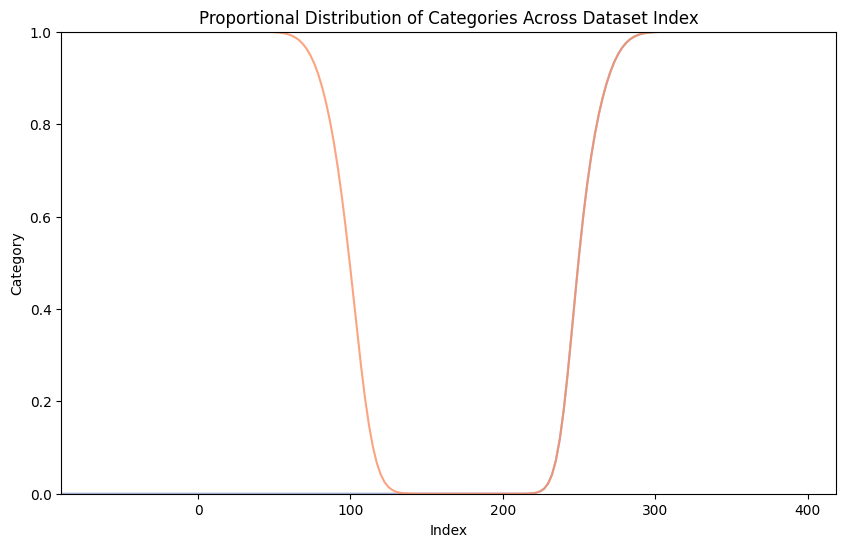

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example dataset
df = pd.DataFrame({
    'cat': ['A'] * 100 + ['B'] * 150 + ['C'] * 80,
})
# df = df.sample(frac=1).reset_index(drop=True)

# Add index
df['idx'] = df.index

# Sort categories
cats_order = df['cat'].value_counts().index

# Plot normalized KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='idx',
    hue='cat',
    fill=False,  # normalize each category independently
    multiple="fill",      # ensures proportion (fills to 1)
    palette='Set2',
    hue_order=cats_order,
    legend=False,
    alpha=0.8
)

plt.title("Proportional Distribution of Categories Across Dataset Index")
plt.xlabel("Index")
plt.ylabel("Category")
plt.show()


In [ ]:
plt.figure(figsize=(48,32))
sns.kdeplot(data=df_train.reset_index(),x ='index',hue='SellerID',fill=True,   
             multiple='fill',alpha=0.7,legend=False)

ConversionError: Failed to convert value(s) to axis units: 0                                    Пылесборник
1                           Крышка для объектива
2         Аксессуар для музыкального инструмента
3                                      Видеоигра
4                                      Видеоигра
                           ...                  
197193                           Паровая станция
197194               Выпрямитель для волос Dyson
197195           Посудомоечная машина компактная
197196                              Наушники TWS
197197       Универсальный пульт для электроники
Name: CommercialTypeName4, Length: 197198, dtype: object

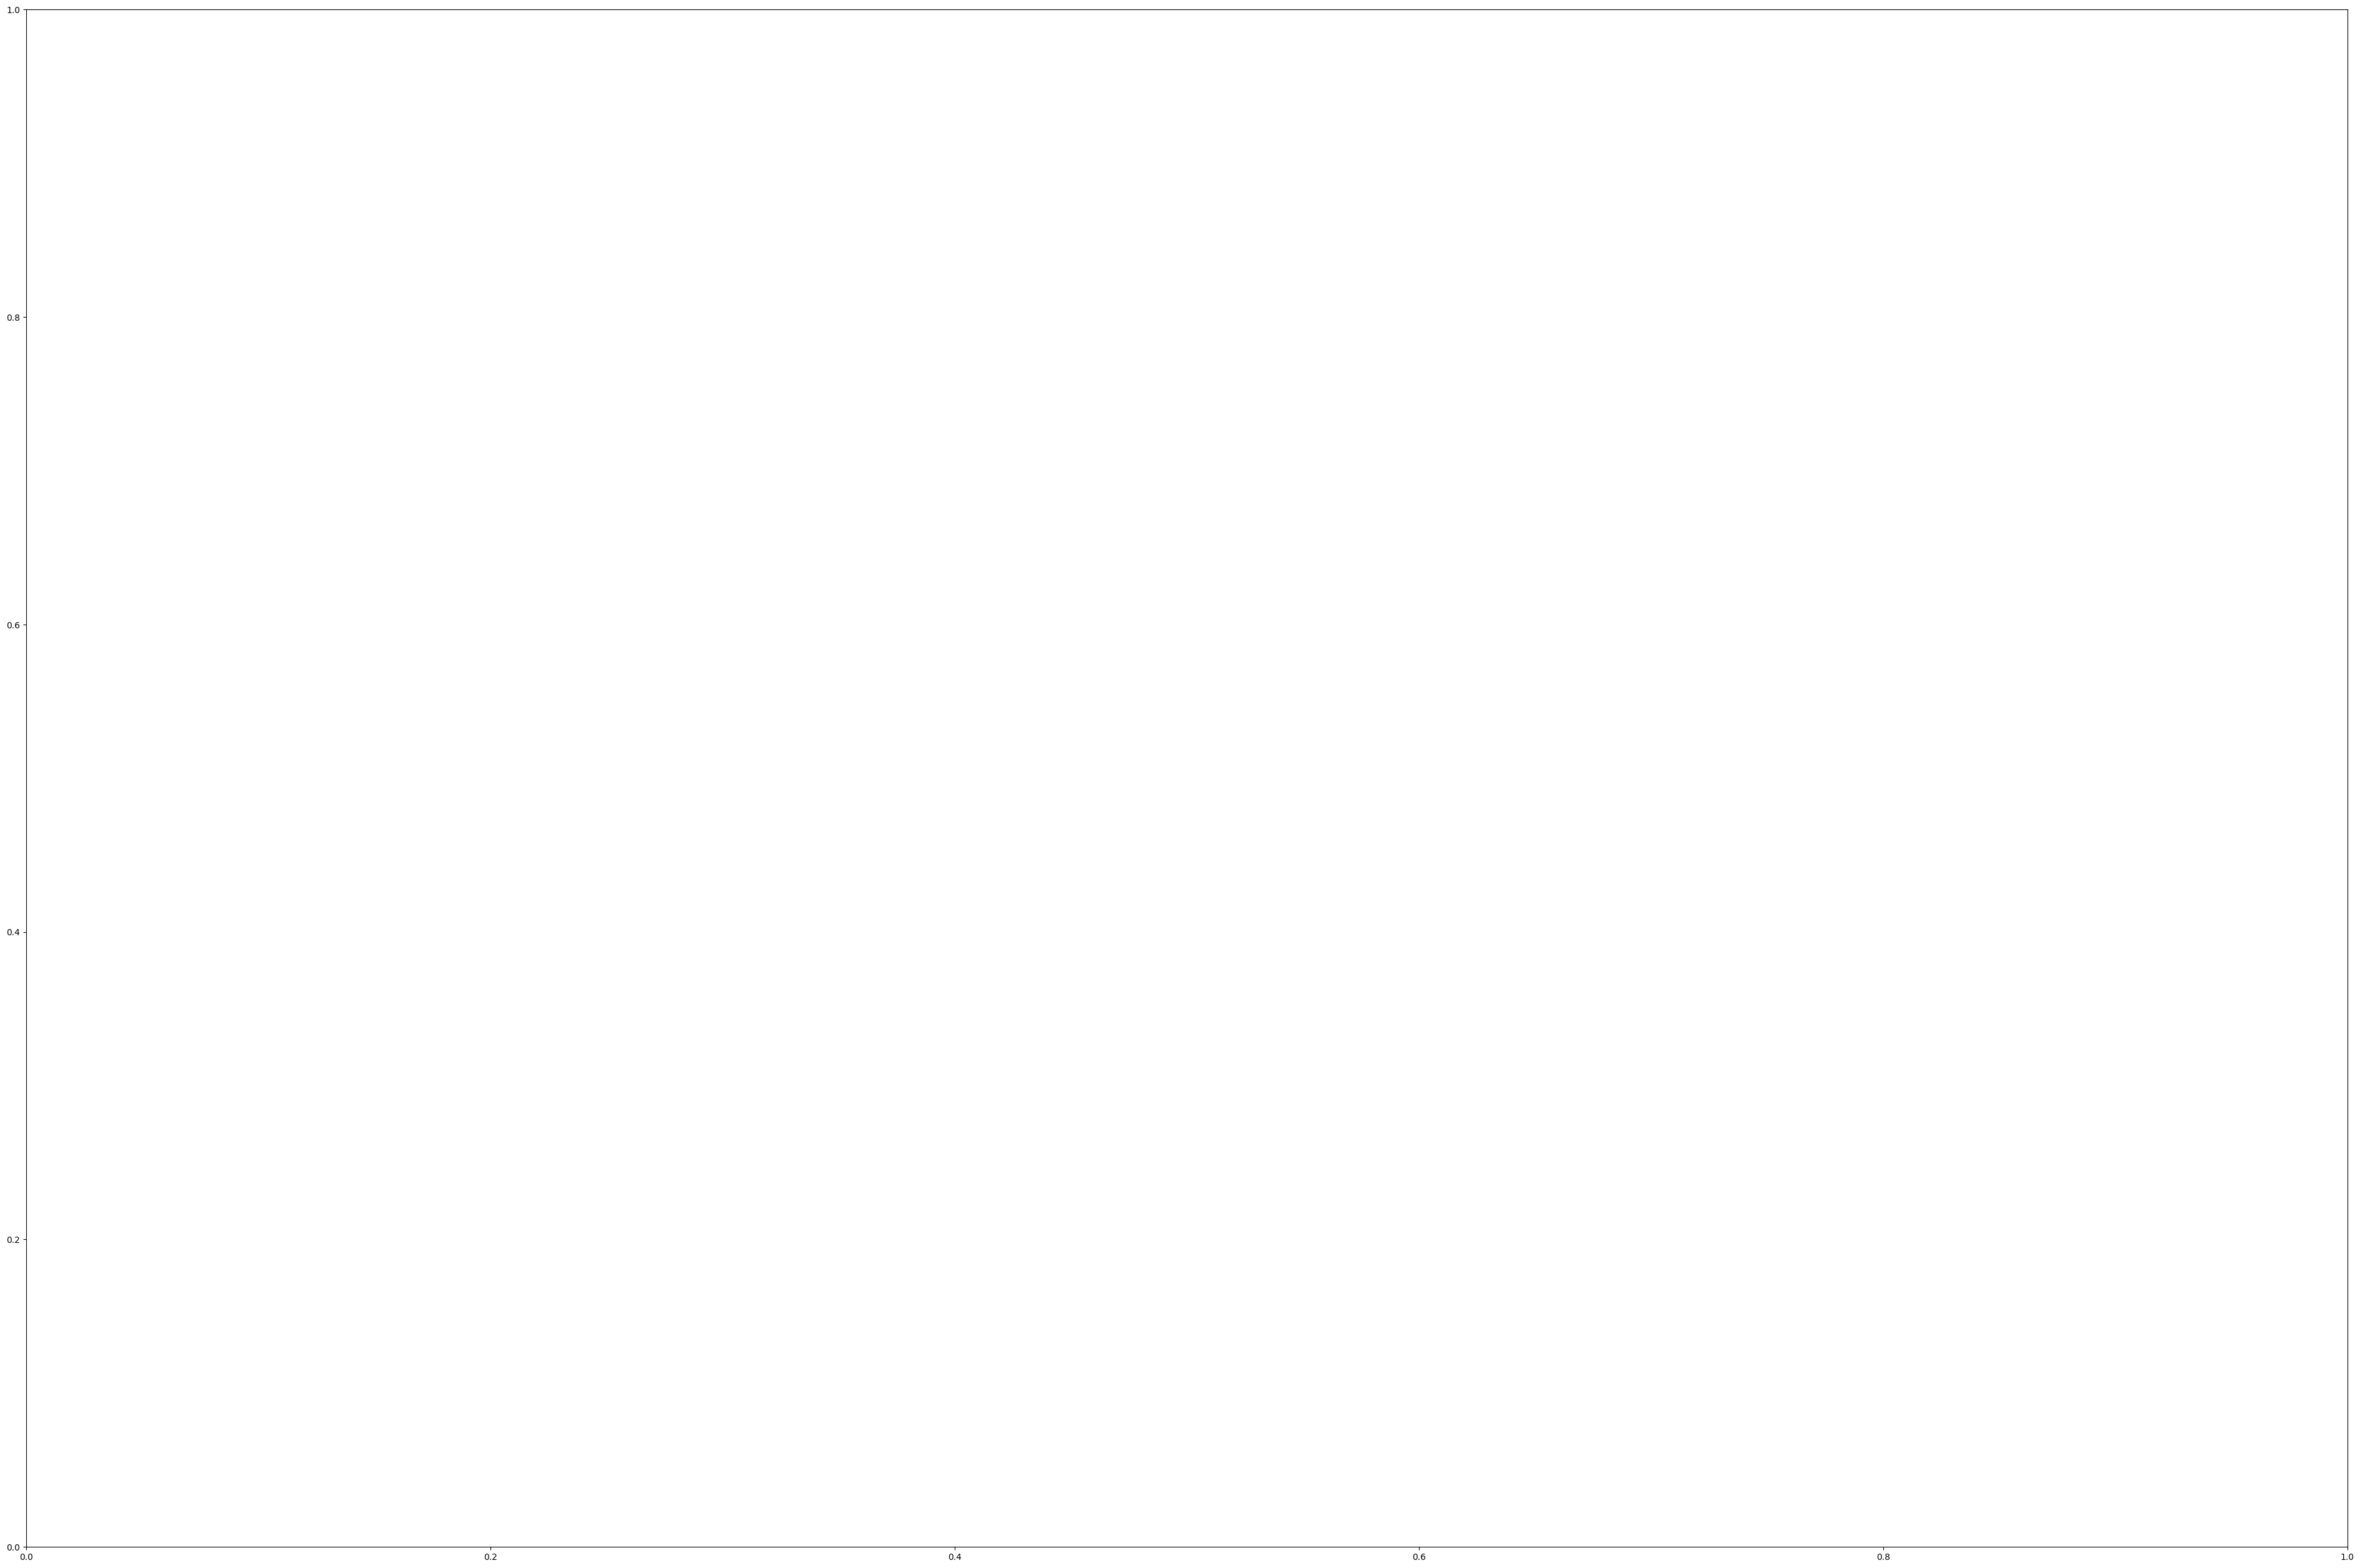

In [ ]:

plt.hist(np.arange(df_train.shape[0]),df_train['CommercialTypeName4'],density=True)

In [12]:
df_test.loc[df_test['SellerID'] == 3995]

,id,resolution,brand_name,description,name_rus,CommercialTypeName4,rating_1_count,rating_2_count,rating_3_count,rating_4_count,...,ExemplarReturnedCountTotal30,ExemplarReturnedCountTotal90,ExemplarReturnedValueTotal7,ExemplarReturnedValueTotal30,ExemplarReturnedValueTotal90,ItemVarietyCount,ItemAvailableCount,seller_time_alive,ItemID,SellerID
45120,70140,1,NaN,Описание<br/><br/>Наушники беспроводные - это ...,беспроводные наушники Air Pro,Моногарнитура Bluetooth,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,520.0,34991,3995
61307,36287,0,NaN,"Беспроводные наушники Pro с микрофоном, анимац...",Беспроводные наушники PodsPro,Моногарнитура Bluetooth,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,NaN,NaN,539.0,18206,3995
71458,61875,1,NaN,"Беспроводные наушники Pro с микрофоном, анимац...",Наушники беспроводные,Моногарнитура Bluetooth,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,0.0,1.0,1.0,559.0,30986,3995


In [15]:
cols = ['brand','name_com','SellerID']
for i in cols:
    train_df,val_df,test_df,artifacts = time_based_stats_threeway(train_df,val_df,test_df,i,'label')

In [22]:
def f1_macro_from_pr(pos_count, neg_count, precision, recall):
    # True Positives and False Negatives for class 1
    TP = recall * pos_count
    FN = pos_count - TP
    
    # False Positives from precision formula
    FP = TP * (1 / precision - 1) if precision > 0 else 0
    
    # For class 0:
    TN = neg_count - FP
    
    # F1 for class 1
    f1_pos = 0.0
    if (precision + recall) > 0:
        f1_pos = 2 * precision * recall / (precision + recall)
    
    # Precision & recall for class 0
    prec_neg = TN / (TN + FN) if (TN + FN) > 0 else 0
    rec_neg = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    # F1 for class 0
    f1_neg = 0.0
    if (prec_neg + rec_neg) > 0:
        f1_neg = 2 * prec_neg * rec_neg / (prec_neg + rec_neg)
    
    # Macro F1
    return (f1_pos + f1_neg) / 2

# Example: 1000 pos, 10000 neg, precision=0.6, recall=0.8
print(f1_macro_from_pr(10000, 10000, 0.8, 0.8))  # ~0.824


0.8000000000000002


In [15]:
10/100

0.1

In [ ]:
# import numpy as np
# import pandas as pd

# def add_14_features(train_df, val_df, test_df,
#                     gmv7="GmvTotal7", gmv30="GmvTotal30", gmv90="GmvTotal90",
#                     photos="photos_published_count", item_variety="ItemVarietyCount",
#                     comments="comments_published_count",
#                     ret_val90="ExemplarReturnedValueTotal90",
#                     ret_count90="ExemplarReturnedCountTotal90",
#                     order_acc90="OrderAcceptedCountTotal90",
#                     fake_ret90="item_count_fake_returns90",
#                     sales7="item_count_sales7", sales30="item_count_sales30", sales90="item_count_sales90",
#                     available="ItemAvailableCount", seller_col="SellerID",
#                     brand_col="brand_name", commercial_col="CommercialTypeName4",
#                     desc_col="description", name_col="name_rus",
#                     rating_cols=None,
#                     alpha=30.0, eps=1e-12):
#     """
#     Compute 14 (plus helper) features for train/val/test using only train-based aggregates.
#     Returns: train_aug, val_aug, test_aug, artifacts

#     artifacts contains:
#       - seller_gmv7_total (dict)
#       - seller_known_set (set)
#       - seller_gmv7_median (float)
#       - brand_count_map (dict)
#       - brand_rank_pct_map (dict)
#       - commercial_full_map (dict)  # smoothed TE
#       - commercial_count_map (dict)
#       - commercial_pos_map (dict)
#       - commercial_global_mean (float)
#     """
#     # copy inputs (do not modify originals)
#     train = train_df.copy().reset_index(drop=True)
#     val = val_df.copy().reset_index(drop=True)
#     test = test_df.copy().reset_index(drop=True)

#     # default rating columns
#     if rating_cols is None:
#         rating_cols = ["rating_1_count","rating_2_count","rating_3_count","rating_4_count","rating_5_count"]

#     # normalize missing keys to safe values
#     for df in (train, val, test):
#         # ensure seller col exists
#         if seller_col not in df.columns:
#             df[seller_col] = np.nan
#         # ensure brand/commercial exist
#         if brand_col not in df.columns:
#             df[brand_col] = np.nan
#         if commercial_col not in df.columns:
#             df[commercial_col] = np.nan
#         # fill description/name with empty strings for length features
#         if desc_col not in df.columns:
#             df[desc_col] = ""
#         if name_col not in df.columns:
#             df[name_col] = ""

#     # --- TRAIN-ONLY AGGREGATES ---
#     # 1) seller_gmv7_total
#     if seller_col in train.columns and gmv7 in train.columns:
#         seller_gmv7_series = train.groupby(seller_col)[gmv7].sum()
#         seller_gmv7_map = seller_gmv7_series.to_dict()
#         seller_gmv7_median = float(seller_gmv7_series.median()) if len(seller_gmv7_series) > 0 else 0.0
#     else:
#         seller_gmv7_map = {}
#         seller_gmv7_median = 0.0

#             # compute median seller_time_alive on train (fallback denominator)
#     if 'seller_time_alive' in train.columns:
#         # for sellers present in the seller_gmv7_map, take the median seller_time_alive
#         seller_time_alive_series = train.groupby(seller_col)['seller_time_alive'].median().dropna()
#         seller_time_alive_median = float(seller_time_alive_series.median()) if len(seller_time_alive_series) > 0 else 1.0
#         # also build map seller -> median seller_time_alive for mapping exact sellers (optional)
#         seller_time_alive_map = seller_time_alive_series.to_dict()
#     else:
#         seller_time_alive_median = 1.0
#         seller_time_alive_map = {}


#     # known sellers set
#     seller_known_set = set(seller_gmv7_map.keys())

#     # 2) brand counts and percentile rank (computed on train only)
#     brand_counts = train[brand_col].fillna("<unk>").value_counts()
#     brand_count_map = brand_counts.to_dict()
#     # percentile rank map (brand -> pct rank among train brands)
#     # compute ranking by count; produce mapping brand -> percentile in (0..1]
#     brand_count_df = brand_counts.reset_index()
#     brand_count_df.columns = [brand_col, "count"]
#     brand_count_df["rank_pct"] = brand_count_df["count"].rank(pct=True).values
#     brand_rank_pct_map = dict(zip(brand_count_df[brand_col], brand_count_df["rank_pct"]))

#     # 3) commercial-type smoothed TE (train-only final map)
#     # compute pos & count on train (for commercial_col)
#     com_series = train[[commercial_col]].copy()
#     com_series[commercial_col] = com_series[commercial_col].fillna("<unk>")
#     # if train contains target column? assume label exists in train
#     # compute pos and count
#     if "label" in train.columns:
#         lab_col = "label"
#     else:
#         # try to find binary column in train; otherwise raise
#         raise ValueError("Train dataframe must contain the binary label column named 'label' or pass precomputed artifacts.")
#     com_stats = train.groupby(commercial_col)[lab_col].agg(['sum','count']).rename(columns={'sum':'pos','count':'total'})
#     # global mean over train
#     if com_stats['pos'].sum() + 0 >= 0:
#         commercial_global_mean = float(train[lab_col].mean())
#     else:
#         commercial_global_mean = 0.0
#     # smoothed TE map
#     com_stats['smoothed'] = (com_stats['pos'] + alpha * commercial_global_mean) / (com_stats['total'] + alpha)
#     commercial_full_map = com_stats['smoothed'].to_dict()
#     commercial_count_map = com_stats['total'].astype(int).to_dict()
#     commercial_pos_map = com_stats['pos'].astype(int).to_dict()

#     # helper function to map with fallback
#     def map_with_fallback(series, mapping, fallback):
#         return series.map(mapping).fillna(fallback)

#     # --- compute features on each df ---
#     def augment(df):
#         D = df.copy()

#         # safe column refs
#         G7 = D.get(gmv7, pd.Series(0, index=D.index))
#         G30 = D.get(gmv30, pd.Series(0, index=D.index))
#         G90 = D.get(gmv90, pd.Series(0, index=D.index))
#         PH = D.get(photos, pd.Series(0, index=D.index))
#         VAR = D.get(item_variety, pd.Series(0, index=D.index))
#         COM = D.get(comments, pd.Series(0, index=D.index))
#         RV90 = D.get(ret_val90, pd.Series(0, index=D.index))
#         RCN90 = D.get(ret_count90, pd.Series(0, index=D.index))
#         O90 = D.get(order_acc90, pd.Series(0, index=D.index))
#         FR90 = D.get(fake_ret90, pd.Series(0, index=D.index))
#         S7 = D.get(sales7, pd.Series(0, index=D.index))
#         S30 = D.get(sales30, pd.Series(0, index=D.index))
#         S90 = D.get(sales90, pd.Series(0, index=D.index))
#         AV = D.get(available, pd.Series(0, index=D.index))
#         seller_ids = D.get(seller_col, pd.Series(np.nan, index=D.index))
#         brands = D.get(brand_col, pd.Series("<unk>", index=D.index)).fillna("<unk>")
#         coms = D.get(commercial_col, pd.Series("<unk>", index=D.index)).fillna("<unk>")

#         # 1) gmv7_to_gmv30
#         D["gmv7_to_gmv30"] = G7 / (G30 + eps)
#         # 2) gmv7_growth_rate
#         expected_gmv7 = G30 * (7.0 / 30.0)
#         D["gmv7_growth_rate"] = (G7 - expected_gmv7) / (G30 + eps)
#         # 3) gmv7_per_available
#         D["gmv7_per_available"] = G7 / (AV.replace(0, np.nan) + eps)
#         D["gmv7_per_available"] = D["gmv7_per_available"].fillna(0.0)
#         # 4) photos_per_variety
#         D["photos_per_variety"] = PH / (VAR + 1.0)
#         D["photos_per_variety"] = D["photos_per_variety"].fillna(0.0)
#         # 5) comments_per_photo
#         D["comments_per_photo"] = COM / (PH + 1.0)
#         D["comments_per_photo"] = D["comments_per_photo"].fillna(0.0)
#         # 6) return_value_rate_90
#         D["return_value_rate_90"] = RV90 / (G90 + eps)
#         # 7) return_count_rate_90
#         D["return_count_rate_90"] = RCN90 / (O90 + eps)
#         # 8) fake_return_rate_90
#         D["fake_return_rate_90"] = FR90 / (S90 + eps)
#         # 9) sales_velocity7_per_day
#         D["sales_velocity7_per_day"] = S7 / 7.0
#         # 10) item_share_of_seller_gmv7
#         # map seller total gmv7 from train; fill with median if missing
#         D["_seller_gmv7_total"] = seller_ids.map(seller_gmv7_map).fillna(seller_gmv7_median)

#         # map per-seller median time alive (train-only); fallback to median if missing
#         seller_time_alive_arr = D.get('seller_time_alive', pd.Series(np.nan, index=D.index))
#         # if you built seller_time_alive_map in artifacts, use it; otherwise fall back
#         D["_seller_time_alive_median_map"] = seller_ids.map(seller_time_alive_map).fillna(seller_time_alive_median).astype(float)
#         # compute seller_gmv7_per_day
#         D["seller_gmv7_per_day"] = D["_seller_gmv7_total"] / (D["_seller_time_alive_median_map"] + eps)
#         # optionally, item-level ratio vs seller per-day: how important is this item vs seller daily volume
#         D["item_gmv7_vs_seller_per_day"] = (G7 / (D["_seller_time_alive_median_map"] + eps)) / (D["_seller_gmv7_total"]/(D["_seller_time_alive_median_map"]+eps) + eps)
#         # the latter simplifies to item_share_of_seller_gmv7 but normalized by time; keep whichever you prefer


#         D["item_share_of_seller_gmv7"] = G7 / (D["_seller_gmv7_total"] + eps)
#         # 11) brand_freq_rank_pct
#         # brand count map from train; unseen => 0 count and rank_pct 0
#         D["_brand_count"] = brands.map(brand_count_map).fillna(0).astype(float)
#         D["brand_freq_rank_pct"] = brands.map(brand_rank_pct_map).fillna(0.0).astype(float)
#         # 12) commercialtype_confidence_te = commercial_te * log1p(count)
#         D["_commercial_te"] = coms.map(commercial_full_map).fillna(commercial_global_mean).astype(float)
#         D["_commercial_count"] = coms.map(commercial_count_map).fillna(0).astype(float)
#         D["commercialtype_confidence_te"] = D["_commercial_te"] * np.log1p(D["_commercial_count"])
#         # 13) description_name_len_ratio
#         desc = D.get(desc_col, pd.Series("", index=D.index)).fillna("").astype(str)
#         nm = D.get(name_col, pd.Series("", index=D.index)).fillna("").astype(str)
#         D["_desc_len"] = desc.str.len()
#         D["_name_len"] = nm.str.len()
#         D["description_name_len_ratio"] = D["_desc_len"] / (D["_name_len"] + 1.0)
#         # 14) weighted_rating_score + total_rating_count
#         # ensure rating_cols exist
#         present_r_cols = [c for c in rating_cols if c in D.columns]
#         if len(present_r_cols) == 5:
#             r1, r2, r3, r4, r5 = present_r_cols
#             num = (1.0 * D[r1] + 2.0 * D[r2] + 3.0 * D[r3] + 4.0 * D[r4] + 5.0 * D[r5])
#             den = D[present_r_cols].sum(axis=1) + eps
#             D["weighted_rating_score"] = num / den
#             D["total_rating_count"] = (den - eps).fillna(0.0)
#         else:
#             # fallback if not all rating cols present
#             # try to sum any present rating cols and approximate weighted score if possible
#             D["total_rating_count"] = D[present_r_cols].sum(axis=1) if len(present_r_cols) > 0 else 0.0
#             # weighted score fallback: use rating_5_count proportion if present
#             if "rating_5_count" in D.columns:
#                 D["weighted_rating_score"] = D["rating_5_count"] / (D["total_rating_count"] + eps)
#             else:
#                 D["weighted_rating_score"] = 0.0

#         # extra helper flags
#         D["seller_known"] = D[seller_col].isin(seller_known_set).astype(int)
#         D["brand_unseen"] = (~D[brand_col].fillna("<unk>").isin(brand_count_map.keys())).astype(int)
#         D["commercial_unseen"] = (~D[commercial_col].fillna("<unk>").isin(commercial_count_map.keys())).astype(int)

#         # drop intermediate helper columns that start with underscore except keep seller_gmv7_total if useful
#         # keep them if you want to analyze, otherwise remove:
#         # D.drop(columns=[c for c in D.columns if c.startswith("_")], inplace=True, errors='ignore')

#         return D

#     train_aug = augment(train)
#     val_aug = augment(val)
#     test_aug = augment(test)

#     artifacts = {
#         "seller_gmv7_map": seller_gmv7_map,
#         "seller_gmv7_median": seller_gmv7_median,
#         "seller_known_set": seller_known_set,
#         "brand_count_map": brand_count_map,
#         "brand_rank_pct_map": brand_rank_pct_map,
#         "commercial_full_map": commercial_full_map,
#         "commercial_count_map": commercial_count_map,
#         "commercial_pos_map": commercial_pos_map,
#         "commercial_global_mean": commercial_global_mean,
#         "alpha": float(alpha),
#         "eps": float(eps),
#         "seller_time_alive_map": seller_time_alive_map,
#         "seller_time_alive_median": seller_time_alive_median
#     }

#     return train_aug, val_aug, test_aug, artifacts


In [1]:
import numpy as np
import pandas as pd
from collections import defaultdict

def add_15_features_causal(train_df, val_df, test_df,
                           label_col="label",
                           gmv7="GmvTotal7", gmv30="GmvTotal30", gmv90="GmvTotal90",
                           photos="photos_published_count", item_variety="ItemVarietyCount",
                           comments="comments_published_count",
                           ret_val90="ExemplarReturnedValueTotal90",
                           ret_count90="ExemplarReturnedCountTotal90",
                           order_acc90="OrderAcceptedCountTotal90",
                           fake_ret90="item_count_fake_returns90",
                           sales7="item_count_sales7", sales30="item_count_sales30", sales90="item_count_sales90",
                           available="ItemAvailableCount", seller_col="SellerID",
                           brand_col="brand_name", commercial_col="CommercialTypeName4",
                           desc_col="description", name_col="name_rus",
                           rating_cols=None,
                           alpha=30.0, eps=1e-12, missing_token="<unk>", prior=None):
    """
    Compute 15 features:
      - causal (prior-only) values for train rows (each row sees only earlier rows)
      - frozen train-based aggregates applied to val/test
    Returns: train_aug, val_aug, test_aug, artifacts
    artifacts contains maps and medians needed at inference.
    """
    # Defensive copies
    train = train_df.copy().reset_index(drop=True)
    val = val_df.copy().reset_index(drop=True)
    test = test_df.copy().reset_index(drop=True)

    if rating_cols is None:
        rating_cols = ["rating_1_count","rating_2_count","rating_3_count","rating_4_count","rating_5_count"]

    # Normalize missing category values
    for df in (train, val, test):
        if seller_col not in df.columns:
            df[seller_col] = np.nan
        if brand_col not in df.columns:
            df[brand_col] = np.nan
        if commercial_col not in df.columns:
            df[commercial_col] = np.nan
        if desc_col not in df.columns:
            df[desc_col] = ""
        if name_col not in df.columns:
            df[name_col] = ""

        df[brand_col] = df[brand_col].fillna(missing_token)
        df[commercial_col] = df[commercial_col].fillna(missing_token)
        df[seller_col] = df[seller_col].fillna(missing_token)

    # Determine prior (initial global mean) if not provided
    if prior is None:
        # Use overall train label mean as pragmatic prior (if available)
        if label_col in train.columns and len(train) > 0:
            prior = float(train[label_col].mean())
        else:
            prior = 0.0

    # ------------------------
    # TRAIN: compute causal (prior-only) stats per row
    # We'll compute per-row prior counts/sums via vectorized groupby cumcount/cumsum (shifted)
    # ------------------------
    T = train.copy()

    # Ensure label exists
    if label_col not in T.columns:
        raise ValueError(f"label_col '{label_col}' not found in train_df")

    # Global prior per row: cumulative pos (shifted) / cumulative count (shifted)
    cum_pos = T[label_col].cumsum().shift(1).fillna(0.0)
    # cum_count_prior for row i is i (0-based)
    cum_count_prior = pd.Series(np.arange(len(T)), index=T.index).astype(float)
    global_mean_prior = np.where(cum_count_prior > 0, cum_pos / (cum_count_prior + eps), prior)
    # convert to Series for vectorized ops
    global_mean_prior = pd.Series(global_mean_prior, index=T.index, dtype=float)

    # ---- categorical (commercial_col) prior pos/count per-row ----
    # prior_count = number of previous occurrences of same category
    com_series = T[commercial_col].fillna(missing_token)
    com_prior_count = com_series.groupby(com_series).cumcount().astype(int)  # prior occurrences
    # prior_pos: cumulative sum of labels per category, shifted by 1
    com_prior_pos = T.groupby(com_series)[label_col].cumsum().shift(1).fillna(0).astype(int)

    # per-row causal smoothed TE:
    # te_prior = (prior_pos + alpha * global_mean_prior) / (prior_count + alpha)
    te_prior = (com_prior_pos + alpha * global_mean_prior) / (com_prior_count + alpha)

    # ---- brand prior counts per row ----
    brand_series = T[brand_col].fillna(missing_token)
    brand_prior_count = brand_series.groupby(brand_series).cumcount().astype(int)

    # ---- seller-level prior totals (seller_gmv7 prior total up to previous rows) ----
    # seller prior gmv7 total:
    if gmv7 in T.columns:
        seller_gmv7_prior = T.groupby(T[seller_col])[gmv7].cumsum().shift(1).fillna(0.0)
    else:
        seller_gmv7_prior = pd.Series(0.0, index=T.index)

    # ---- seller prior time alive: use seller_time_alive if present as-is (no causal change) ----
    # for per-day rates we'll map seller->median seller_time_alive from train (frozen), but for train row, use seller mapping if available
    # compute seller median time alive (train-wide)
    if "seller_time_alive" in train.columns:
        seller_time_alive_map = train.groupby(seller_col)["seller_time_alive"].median().to_dict()
        seller_time_alive_median = float(pd.Series(list(seller_time_alive_map.values())).median()) if len(seller_time_alive_map)>0 else 1.0
    else:
        seller_time_alive_map = {}
        seller_time_alive_median = 1.0

    # ---- other per-row derived features (these are item-level and do not require causal reduction) ----
    # We'll compute the static per-row features for train; they are identical for val/test except when using frozen maps later
    def compute_row_level_basic(df):
        G7 = df.get(gmv7, pd.Series(0.0, index=df.index)).astype(float)
        G30 = df.get(gmv30, pd.Series(0.0, index=df.index)).astype(float)
        G90 = df.get(gmv90, pd.Series(0.0, index=df.index)).astype(float)
        PH = df.get(photos, pd.Series(0.0, index=df.index)).astype(float)
        VAR = df.get(item_variety, pd.Series(0.0, index=df.index)).astype(float)
        COM = df.get(comments, pd.Series(0.0, index=df.index)).astype(float)
        RV90 = df.get(ret_val90, pd.Series(0.0, index=df.index)).astype(float)
        RCN90 = df.get(ret_count90, pd.Series(0.0, index=df.index)).astype(float)
        O90 = df.get(order_acc90, pd.Series(0.0, index=df.index)).astype(float)
        FR90 = df.get(fake_ret90, pd.Series(0.0, index=df.index)).astype(float)
        S7 = df.get(sales7, pd.Series(0.0, index=df.index)).astype(float)
        S30 = df.get(sales30, pd.Series(0.0, index=df.index)).astype(float)
        S90 = df.get(sales90, pd.Series(0.0, index=df.index)).astype(float)
        AV = df.get(available, pd.Series(0.0, index=df.index)).astype(float)
        return dict(G7=G7, G30=G30, G90=G90, PH=PH, VAR=VAR, COM=COM,
                    RV90=RV90, RCN90=RCN90, O90=O90, FR90=FR90,
                    S7=S7, S30=S30, S90=S90, AV=AV)

    basic = compute_row_level_basic(T)

    # Start building train augmented frame
    train_aug = T.copy()

    # Feature 1: gmv7_to_gmv30
    train_aug["num_gmv7_to_gmv30"] = basic["G7"] / (basic["G30"] + eps)
    # Feature 2: gmv7_growth_rate
    expected_gmv7 = basic["G30"] * (7.0 / 30.0)
    train_aug["num_gmv7_growth_rate"] = (basic["G7"] - expected_gmv7) / (basic["G30"] + eps)
    # Feature 3: gmv7_per_available
    train_aug["num_gmv7_per_available"] = basic["G7"] / (basic["AV"].replace(0, np.nan) + eps)
    train_aug["num_gmv7_per_available"] = train_aug["num_gmv7_per_available"].fillna(0.0)
    # Feature 4: photos_per_variety
    train_aug["num_photos_per_variety"] = basic["PH"] / (basic["VAR"] + 1.0)
    # Feature 5: comments_per_photo
    train_aug["num_comments_per_photo"] = basic["COM"] / (basic["PH"] + 1.0)
    # Feature 6: return_value_rate_90
    train_aug["num_return_value_rate_90"] = basic["RV90"] / (basic["G90"] + eps)
    # Feature 7: return_count_rate_90
    train_aug["num_return_count_rate_90"] = basic["RCN90"] / (basic["O90"] + eps)
    # Feature 8: fake_return_rate_90
    train_aug["num_fake_return_rate_90"] = basic["FR90"] / (basic["S90"] + eps)
    # Feature 9: sales_velocity7_per_day
    train_aug["num_sales_velocity7_per_day"] = basic["S7"] / 7.0

    # Feature 10: item_share_of_seller_gmv7 (use seller prior total for causal)
    num__seller_gmv7_prior_total = seller_gmv7_prior.fillna(0.0)
    train_aug["num_item_share_of_seller_gmv7"] = basic["G7"] / (num__seller_gmv7_prior_total + eps)
    

    # Feature 11: brand_freq_rank_pct (use brand prior count percentile among train prior counts)
    # For train causal: compute brand prior counts per row -> then compute percentile ranks per-row (approx via rank on unique prior counts)
    brand_prior_count = brand_prior_count.astype(float)
    # Map unique prior counts to percentile rank using distribution of final brand counts (train-wide)
    # Compute final brand counts distribution to convert prior counts into approx percentiles
    final_brand_counts = train[brand_col].value_counts().sort_values(ascending=True)
    # Build mapping from count -> percentile by using final distribution; small nuance but acceptable approximation
    count_vals = final_brand_counts.values
    # mapping count -> percentile (for the count values encountered)
    unique_counts = np.unique(count_vals)
    # simple mapping: count -> (rank among unique_counts)/len(unique_counts)
    count_to_pct = {int(c): float(np.searchsorted(unique_counts, c) / max(1, len(unique_counts)-1)) for c in unique_counts}
    # fallback: if count not in unique_counts map to 0
    train_aug["num_brand_freq_rank_pct"] = brand_prior_count.map(count_to_pct).fillna(0.0).astype(float)

    # final commercial smoothed TE map (train-wide)
    com_stats_full = train.groupby(commercial_col)[label_col].agg(['sum','count']).rename(columns={'sum':'pos','count':'total'})
    commercial_global_mean_final = float(train[label_col].mean())
    com_stats_full['smoothed'] = (com_stats_full['pos'] + alpha * commercial_global_mean_final) / (com_stats_full['total'] + alpha)
    commercial_full_map = com_stats_full['smoothed'].to_dict()
    commercial_count_map = com_stats_full['total'].astype(int).to_dict()
    commercial_pos_map = com_stats_full['pos'].astype(int).to_dict()
    # Feature 12: commercialtype_confidence_te (per-row causal TE times log1p(prior_count))
    num__commercial_prior_count = com_prior_count.astype(float)
    num__commercial_prior_pos = com_prior_pos.astype(float)
    num_num_ = (num__commercial_prior_pos + alpha * global_mean_prior) / (num__commercial_prior_count + alpha)
    train_aug["num_commercialtype_confidence_te"] = num_num_ * np.log1p(num__commercial_prior_count)

    # Feature 13: description_name_len_ratio
    desc = train[desc_col].fillna("").astype(str)
    nm = train[name_col].fillna("").astype(str)
    train_aug["num__desc_len"] = desc.str.len()
    train_aug["num__name_len"] = nm.str.len()
    train_aug["num_description_name_len_ratio"] = train_aug["num__desc_len"] / (train_aug["num__name_len"] + 1.0)

    # Feature 14: weighted_rating_score + total_rating_count (item-level, no causal aggregation needed)
    present_r_cols = [c for c in rating_cols if c in train.columns]
    if len(present_r_cols) == 5:
        r1, r2, r3, r4, r5 = present_r_cols
        num = (1.0 * train[r1] + 2.0 * train[r2] + 3.0 * train[r3] + 4.0 * train[r4] + 5.0 * train[r5])
        den = train[present_r_cols].sum(axis=1) + eps
        train_aug["num_weighted_rating_score"] = num / den
        train_aug["num_total_rating_count"] = (den - eps).fillna(0.0)
    else:
        train_aug["num_total_rating_count"] = train[present_r_cols].sum(axis=1) if len(present_r_cols)>0 else 0.0
        if "rating_5_count" in train.columns:
            train_aug["num_weighted_rating_score"] = train["rating_5_count"] / (train_aug["num_total_rating_count"] + eps)
        else:
            train_aug["num_weighted_rating_score"] = 0.0

    # Feature 15: seller_gmv7_per_day (use seller prior gmv7 total and seller_time_alive mapping from train)
    # seller_time_alive_map from train (median)


    # helper flags for train




    # ------------------------
    # Build frozen final maps from full train (for val/test)
    # ------------------------
    # final seller_gmv7 totals (train-wide)
    if gmv7 in train.columns:
        seller_gmv7_final = train.groupby(seller_col)[gmv7].sum().to_dict()
        seller_gmv7_final_median = float(pd.Series(list(seller_gmv7_final.values())).median()) if len(seller_gmv7_final)>0 else 0.0
    else:
        seller_gmv7_final = {}
        seller_gmv7_final_median = 0.0
    train_aug["num__seller_gmv7_total"] = train_aug[seller_col].map(seller_gmv7_final).fillna(seller_gmv7_final_median)


    # final brand counts & rank pct (train-wide)
    brand_count_train = train[brand_col].fillna(missing_token).value_counts().to_dict()
    # rank pct mapping using train counts
    brand_count_series = pd.Series(brand_count_train)
    # percentile rank by count (map brand->rankpct)
    brand_rank_pct_map = (brand_count_series.rank(pct=True)).to_dict()






    # final seller_time_alive map and median
    if "seller_time_alive" in train.columns:
        seller_time_alive_final_map = train.groupby(seller_col)["seller_time_alive"].median().to_dict()
        seller_time_alive_final_median = float(pd.Series(list(seller_time_alive_final_map.values())).median()) if len(seller_time_alive_final_map)>0 else 1.0
    else:
        seller_time_alive_final_map = {}
        seller_time_alive_final_median = 1.0

    if "seller_time_alive" in train.columns:
        seller_time_alive_map = train.groupby(seller_col)["seller_time_alive"].median().to_dict()
        # for train rows, map or fallback to median
        train_aug["num__seller_time_alive_map"] = train[seller_col].map(seller_time_alive_map).fillna(seller_time_alive_median if 'seller_time_alive_median' in locals() else 1.0).astype(float)
    else:
        train_aug["num__seller_time_alive_map"] = pd.Series(1.0, index=train.index)
        
    train_aug["num_seller_gmv7_per_day"] = num__seller_gmv7_prior_total / (train_aug["num__seller_time_alive_map"] + eps)
    train_aug["num_gmv30_per_day"] = train_aug['num_GmvTotal30']/30
    train_aug["num_item_gmv7_vs_seller_per_day"] = (basic["G7"] / (train_aug["num__seller_time_alive_map"] + eps)) / ( (num__seller_gmv7_prior_total / (train_aug["num__seller_time_alive_map"] + eps)) + eps)

    # train_aug["num_seller_known"] = train[seller_col].isin(train[seller_col].unique()).astype(int)  # always 1 in train
    # train_aug["num_brand_unseen"] = 0  # in-train no unseen
    # train_aug["num_commercial_unseen"] = 0
    
    # ------------------------
    # Apply frozen maps to val and test (vectorized)
    # ------------------------
    def augment_with_frozen(df):
        D = df.copy().reset_index(drop=True)
        basic = compute_row_level_basic(D)
        # base features (same formulas as train)
        D["num_gmv7_to_gmv30"] = basic["G7"] / (basic["G30"] + eps)
        expected_gmv7 = basic["G30"] * (7.0 / 30.0)
        D["num_gmv7_growth_rate"] = (basic["G7"] - expected_gmv7) / (basic["G30"] + eps)
        D["num_gmv7_per_available"] = basic["G7"] / (basic["AV"].replace(0, np.nan) + eps)
        D["num_gmv7_per_available"] = D["num_gmv7_per_available"].fillna(0.0)
        D["num_photos_per_variety"] = basic["PH"] / (basic["VAR"] + 1.0)
        D["num_comments_per_photo"] = basic["COM"] / (basic["PH"] + 1.0)
        D["num_return_value_rate_90"] = basic["RV90"] / (basic["G90"] + eps)
        D["num_return_count_rate_90"] = basic["RCN90"] / (basic["O90"] + eps)
        D["num_fake_return_rate_90"] = basic["FR90"] / (basic["S90"] + eps)
        D["num_sales_velocity7_per_day"] = basic["S7"] / 7.0

        # map seller prior totals from final train map (frozen)
        D["num__seller_gmv7_total"] = D[seller_col].map(seller_gmv7_final).fillna(seller_gmv7_final_median)
        D["num_item_share_of_seller_gmv7"] = basic["G7"] / (D["num__seller_gmv7_total"] + eps)

        # brand freq/rank
        # D["num__brand_count"] = D[brand_col].fillna(missing_token).map(brand_count_train).fillna(0).astype(float)
        D["num_brand_freq_rank_pct"] = D[brand_col].fillna(missing_token).map(brand_rank_pct_map).fillna(0.0).astype(float)

        # commercial TE + confidence
        num_commercial_te = D[commercial_col].fillna(missing_token).map(commercial_full_map).fillna(commercial_global_mean_final).astype(float)
        num_commercial_count = D[commercial_col].fillna(missing_token).map(commercial_count_map).fillna(0).astype(float)
        D["num_commercialtype_confidence_te"] = num_commercial_te * np.log1p(num_commercial_count)

        # description/name len ratio
        desc = D.get(desc_col, pd.Series("", index=D.index)).fillna("").astype(str)
        nm = D.get(name_col, pd.Series("", index=D.index)).fillna("").astype(str)
        D["num__desc_len"] = desc.str.len()
        D["num__name_len"] = nm.str.len()
        D["num_description_name_len_ratio"] = D["num__desc_len"] / (D["num__name_len"] + 1.0)

        # weighted rating score
        present_r_cols = [c for c in rating_cols if c in D.columns]
        if len(present_r_cols) == 5:
            r1, r2, r3, r4, r5 = present_r_cols
            num = (1.0 * D[r1] + 2.0 * D[r2] + 3.0 * D[r3] + 4.0 * D[r4] + 5.0 * D[r5])
            den = D[present_r_cols].sum(axis=1) + eps
            D["num_weighted_rating_score"] = num / den
            D["num_total_rating_count"] = (den - eps).fillna(0.0)
        else:
            D["num_total_rating_count"] = D[present_r_cols].sum(axis=1) if len(present_r_cols)>0 else 0.0
            if "rating_5_count" in D.columns:
                D["num_weighted_rating_score"] = D["num_rating_5_count"] / (D["num_total_rating_count"] + eps)
            else:
                D["num_weighted_rating_score"] = 0.0

        # seller_time_alive mapping (train-based final)
        D["num__seller_time_alive_map"] = D[seller_col].map(seller_time_alive_final_map).fillna(seller_time_alive_final_median).astype(float)
        D["num_seller_gmv7_per_day"] = D["num__seller_gmv7_total"] / (D["num__seller_time_alive_map"] + eps)
        D["num_gmv30_per_day"] = D['num_GmvTotal30']/30
        D["num_item_gmv7_vs_seller_per_day"] = (basic["G7"] / (D["num__seller_time_alive_map"] + eps)) / ((D["num__seller_gmv7_total"] / (D["num__seller_time_alive_map"] + eps)) + eps)

        # helper flags
        # D["num_seller_known"] = D[seller_col].isin(seller_gmv7_final.keys()).astype(int)
        # D["num_brand_unseen"] = (~D[brand_col].fillna(missing_token).isin(brand_count_train.keys())).astype(int)
        # D["num_commercial_unseen"] = (~D[commercial_col].fillna(missing_token).isin(commercial_count_map.keys())).astype(int)

        return D

    val_aug = augment_with_frozen(val)
    test_aug = augment_with_frozen(test)

    # ------------------------
    # Artifacts to return (frozen train-wide maps) for inference
    # ------------------------
    artifacts = {
        "seller_gmv7_final_map": seller_gmv7_final,
        "seller_gmv7_final_median": seller_gmv7_final_median,
        "brand_count_train_map": brand_count_train,
        "brand_rank_pct_map": brand_rank_pct_map,
        "commercial_full_map": commercial_full_map,
        "commercial_count_map": commercial_count_map,
        "commercial_pos_map": commercial_pos_map,
        "commercial_global_mean_final": commercial_global_mean_final,
        "seller_time_alive_final_map": seller_time_alive_final_map,
        "seller_time_alive_final_median": seller_time_alive_final_median,
        "alpha": float(alpha),
        "eps": float(eps),
        "missing_token": missing_token
    }

    return train_aug, val_aug, test_aug, artifacts


In [19]:
train_aug,val_aug,test_aug,artifacts = add_15_features_causal(train_df,val_df,test_df)

In [20]:
cols = cols+['desc']

In [ ]:
c = 0


for i in val_aug.columns:

    if i.startswith("num_"):
        if i not in train_aug.columns:
            print(i)
        c+=1
print(c)

296


In [22]:
train_aug = train_aug[val_aug.columns]

In [49]:
train_out = train_aug.drop(cols,axis=1)
val_out = val_aug.drop(cols,axis=1)
test_out = test_aug.drop(cols,axis=1)


In [23]:
train_out.groupby("Seller").count()

NameError: name 'train_out' is not defined

In [ ]:
train_out.to_csv("counterfeit_multimodal/data/full_ts_s.csv")
val_out.to_csv("counterfeit_multimodal/data/val_ts_s.csv")
test_out.to_csv("counterfeit_multimodal/data/test_ts_s.csv")

In [25]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from transformers import AutoImageProcessor, AutoModel
import pickle
from lit_module import LitCounterfeit


from transformers import Blip2Model,BlipModel
from typing import Tuple
import torch.nn.functional as F
from features_extraction import extract_features
from tensorboardX import SummaryWriter
import pickle
import numpy as np
import math

class ImageDataset(Dataset):
    def __init__(self, X_ids,X_features,y=None, img_dir=None, processor=None, target_col="target"):
        # self.df = df.reset_index(drop=True)
        self.X_ids = X_ids
        # self.X_features = X_features
        self.y = y
        self.img_dir = img_dir
        self.processor = processor
        self.target_col = target_col

 

    def __len__(self):
        return self.X_ids.shape[0]

    def __getitem__(self, idx):
        img_idx = self.X_ids.iloc[idx]
        if os.path.exists(os.path.join(self.img_dir, f"{img_idx}.png")):
            img_path = os.path.join(self.img_dir, f"{img_idx}.png")
            image = Image.open(img_path).convert("RGB")
        else:
            image = Image.open("dummy.png").convert("RGB")

        inputs = self.processor(image, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        return inputs
        # # inputs["features_embedding"] = torch.tensor(self.X_features.iloc[idx],dtype=torch.float)
        # if self.y is not None:
        #     target = self.y.iloc[idx]
        #     return inputs, target
        # else:
        #     real_id = self.X_features.iloc[idx].name
        #     return inputs, real_id

X_train_ids = pickle.load(open("X_train_ids.pkl","rb"))
X_val_ids = pickle.load(open("X_val_ids.pkl","rb"))
X_train_split = pickle.load(open("X_train_split.pkl","rb"))
X_val_split = pickle.load(open("X_val_split.pkl","rb"))
y_train_split = pickle.load(open("y_train_split.pkl","rb"))
y_val_split = pickle.load(open("y_val_split.pkl","rb"))
X_test_ids = pickle.load(open("X_test_ids.pkl","rb"))
X_test = pickle.load(open("X_test.pkl","rb"))
# Train/val split
# df_train, df_val = df.iloc[:3], df.iloc[3:]

# model_name = MODEL_NAME
processor = AutoImageProcessor.from_pretrained("Salesforce/blip2-opt-2.7b-coco")
train_ds = ImageDataset(X_train_ids,X_train_split,y_train_split, img_dir="ml_ozon_сounterfeit_train_images", processor=processor)
val_ds = ImageDataset(X_val_ids,X_val_split,y_val_split, img_dir="ml_ozon_сounterfeit_train_images", processor=processor)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=False,num_workers=0)
val_loader = DataLoader(val_ds, batch_size=4,shuffle=False,num_workers=0)
inference_ds = ImageDataset(X_test_ids,X_test,y=None, img_dir="ml_ozon_сounterfeit_test_images", processor=processor)
inference_loader = DataLoader(inference_ds, batch_size=4,shuffle =False,num_workers=0)
# if TRAIN:
#     train_ds = ImageDataset(X_train_ids,X_train_split,y_train_split, img_dir="ml_ozon_сounterfeit_train_images", processor=processor)
#     val_ds = ImageDataset(X_val_ids,X_val_split,y_val_split, img_dir="ml_ozon_сounterfeit_train_images", processor=processor)
# else:
#     inference_ds = ImageDataset(X_test_ids,X_test,y=None, img_dir="ml_ozon_сounterfeit_test_images", processor=processor)

# if TRAIN:
#     train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,num_workers=4)
#     val_loader = DataLoader(val_ds, batch_size=64,num_workers=4)
# else:
#     inference_loader = DataLoader(inference_ds, batch_size=32,num_workers=4)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = BlipModel.from_pretrained("Salesforce/blip-image-captioning-large",torch_dtype = torch.float16).cuda()
device = 'cuda'
# cp = torch.load("best_model0.pt")

CP = "runs/tb/version_9/checkpoints/best-epoch=00-val_f1=0.0000-v1.pth"
# CP=None

cfg = OmegaConf.load("configs/config.yaml")
pl.seed_everything(cfg.seed, workers=True)

dm = CounterfeitDataModule(cfg)
# model = LitCounterfeit.load_from_checkpoint("runs/tb/version_41/checkpoints/best-epoch=00-val_f1=0.0000.ckpt")
model = LitCounterfeit(cfg,CP).to('cuda')



# train_embeddings = []
# model.eval()
# with torch.no_grad():
#     for images in tqdm(train_loader):
#         images = {k: v.to(device) for k, v in images.items()}
#         train_embeddings.append(model.vision.model(batch["image"]))



ModuleNotFoundError: No module named 'lit_module'

In [ ]:
df_test = pd.read_csv("ml_ozon_counterfeit_test.csv")

In [51]:
import pandas as pd

In [40]:
X_train = pd.read_csv("counterfeit_multimodal/data/train_ts_s.csv")
X_val = pd.read_csv("counterfeit_multimodal/data/val_ts_s.csv")
X_test = pd.read_csv("counterfeit_multimodal/data/test_ts_s.csv")

In [43]:
cols_to_drop = [col for col in X_val.columns if col.startswith('num_') and col in drop_feats_val+drop_feats]

In [44]:
X_train = X_train.drop(cols_to_drop,axis=1)
X_test = X_test.drop(cols_to_drop,axis=1)
X_val=X_val.drop(cols_to_drop,axis=1)
X_train.to_csv("counterfeit_multimodal/data/train_truncated.csv")
X_val.to_csv("counterfeit_multimodal/data/val_truncated.csv")
X_test.to_csv("counterfeit_multimodal/data/test_truncated.csv")

In [47]:
X_train
cols = [col for col in X_val.columns if col.startswith('num_')]

In [48]:
X_train[cols].shape

(175000, 38)

In [4]:
X_train = X_train[cols]
X_val = X_val[cols]
X_test = X_test[cols]

In [31]:
drop_feats_val = drop_feats.copy()

In [39]:
X_train

,num_rating_1_count,num_rating_2_count,num_rating_3_count,num_rating_4_count,num_rating_5_count,num_comments_published_count,num_photos_published_count,num_videos_published_count,num_PriceDiscounted,num_item_time_alive,...,num_commercialtype_confidence_te,num__desc_len,num__name_len,num_description_name_len_ratio,num_total_rating_count,num_weighted_rating_score,num__seller_time_alive_map,num_seller_gmv7_per_day,num_gmv30_per_day,num_item_gmv7_vs_seller_per_day
0,6.0,4.0,4.0,3.0,32.0,3.0,6.0,0.0,688.436773,195,...,0.000000,0,74,0.0,0.0,0.0,1.0,0.0,47.301520,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,663.157297,972,...,0.000000,0,50,0.0,0.0,0.0,1.0,0.0,51.152475,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,606.573197,1596,...,0.000000,0,32,0.0,0.0,0.0,1.0,0.0,46.824273,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,856.755162,386,...,0.000000,0,54,0.0,0.0,0.0,1.0,0.0,44.262792,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,822.274833,428,...,0.000000,0,58,0.0,0.0,0.0,1.0,0.0,44.263042,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,744.565723,193,...,0.786944,0,35,0.0,0.0,0.0,1.0,0.0,42.844451,0.0
174996,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,788.587924,193,...,0.786940,0,53,0.0,0.0,0.0,1.0,0.0,42.844338,0.0
174997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,737.820094,193,...,0.786935,0,43,0.0,0.0,0.0,1.0,0.0,42.844918,0.0
174998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,618.973572,341,...,0.786931,0,55,0.0,0.0,0.0,1.0,0.0,42.844302,0.0


In [ ]:
# X_train_feats = pd.concat([X_train_red,X_val_red])

In [35]:
drop_feats = list(imp.head(3).index)   # from your importance series
# drop from train/val/test featureframes X_train_features, X_val_features, X_test_features
X_val_red = X_val.drop(columns=drop_feats, errors='ignore').drop(columns=drop_feats_val, errors='ignore')
X_train_red   = X_train.drop(columns=drop_feats, errors='ignore').drop(columns=drop_feats_val, errors='ignore')
X_test_red  = X_test.drop(columns=drop_feats, errors='ignore').drop(columns=drop_feats_val, errors='ignore')

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
# X_train_ids = pickle.load(open("X_train_ids.pkl","rb"))
# X_val_ids = pickle.load(open("X_val_ids.pkl","rb"))
X_train_split = pickle.load(open("X_train_split.pkl","rb"))
X_val_split = pickle.load(open("X_val_split.pkl","rb"))
y_train_split = pickle.load(open("y_train_split.pkl","rb"))
y_val_split = pickle.load(open("y_val_split.pkl","rb"))
# X_test_ids = pickle.load(open("X_test_ids.pkl","rb"))
X_test = pickle.load(open("X_test.pkl","rb"))

In [ ]:
# df = X_train_split
# df['PriceDiscounted'] = np.log1p(df['PriceDiscounted'])
# df['GmvTotal7'] = np.log1p(df['GmvTotal7'])
# df['GmvTotal30'] = np.log1p(df['GmvTotal30'])
# df['GmvTotal90'] = np.log1p(df['GmvTotal90'])
# df = X_val_split
# df['PriceDiscounted'] = np.log1p(df['PriceDiscounted'])
# df['GmvTotal7'] = np.log1p(df['GmvTotal7'])
# df['GmvTotal30'] = np.log1p(df['GmvTotal30'])
# df['GmvTotal90'] = np.log1p(df['GmvTotal90'])
# df = X_test
# df['PriceDiscounted'] = np.log1p(df['PriceDiscounted'])
# df['GmvTotal7'] = np.log1p(df['GmvTotal7'])
# df['GmvTotal30'] = np.log1p(df['GmvTotal30'])
# df['GmvTotal90'] = np.log1p(df['GmvTotal90'])

,index,Unnamed: 0,id,num_rating_1_count,num_rating_2_count,num_rating_3_count,num_rating_4_count,num_rating_5_count,num_comments_published_count,num_photos_published_count,...,text,SellerID,num_CommercialTypeName4_freq,num_CommercialTypeName4_count,num_CommercialTypeName4_is_top,num_CommercialTypeName4_te,num_brand_name_freq,num_brand_name_count,num_brand_name_is_top,num_brand_name_te
0,0,0,17384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,<BRAND>: <unk></s><DESCRIPTION>: Приветствую М...,398,0.032125,6335,1,0.006313,0.408376,80531,0,0.097645
1,1,1,260316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,<BRAND>: Canon</s><DESCRIPTION>: Тип товара Но...,576,0.043459,8570,1,0.010941,0.000517,102,1,0.080983
2,2,2,10610,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,<BRAND>: __OTHER__</s><DESCRIPTION>: Электронн...,1946,0.002972,586,1,0.027216,0.000025,5,0,0.089171
3,3,3,205236,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,<BRAND>: GALAXY LINE</s><DESCRIPTION>: Мультив...,697,0.000259,51,0,0.151197,0.001212,239,1,0.011451
4,4,4,308655,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,<BRAND>: MAUNFELD</s><DESCRIPTION>: Чайники с ...,1575,0.002561,505,1,0.378936,0.000380,75,1,0.074475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22755,22755,22755,423002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,<BRAND>: <unk></s><DESCRIPTION>: Уникальный си...,9051,0.000350,69,0,0.151197,0.408376,80531,0,0.097645
22756,22756,22756,316386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,<BRAND>: GARLYN</s><DESCRIPTION>: <unk></s><NA...,1841,0.001060,209,1,0.259882,0.000421,83,1,0.032401
22757,22757,22757,245410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,<BRAND>: Dell</s><DESCRIPTION>: Dell Preci ion...,9888,0.032125,6335,1,0.006313,0.000228,45,1,0.045362
22758,22758,22758,440579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,<BRAND>: <unk></s><DESCRIPTION>: Кабель оптиче...,128,0.051684,10192,1,0.001007,0.408376,80531,0,0.097645


In [30]:
# X_train_features, X_test_features: DataFrames with your features (no labels)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
X_train_features = train_df.drop(['Unnamed: 0','id','text','image_path'],axis=1)
X_test_features = test_df.drop(['Unnamed: 0','id','text','image_path'],axis=1)
def adv_auc(X_train_features, X_test_features):
    X = pd.concat([X_train_features, X_test_features], ignore_index=True).fillna(0)
    y = np.concatenate([np.zeros(len(X_train_features)), np.ones(len(X_test_features))])
    clf = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=0,verbose=0)
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    return cross_val_score(clf, X, y, scoring='roc_auc', cv=cv).mean()

print("adv AUC train->test:", adv_auc(X_train_features, X_test_features))


adv AUC train->test: 0.9999999641039778


In [ ]:
# adv_imp = pd.Series({f'num_{k}':v for k,v in pd.read_csv("counterfeit_multimodal/data/adv_importance.csv",index_col = 0).to_dict()['0'].items()})

In [3]:
adv_imp = pd.Series({k:v for k,v in pd.read_csv("counterfeit_multimodal/data/adv_importance.csv",index_col = 0).to_dict()['0'].items()})

In [4]:
num_cols = [col for col in X_train_split.columns]

In [5]:
import numpy as np

In [6]:
def _add_noise(x,noise_std,noise_factor):
    """
    Adds Gaussian noise scaled per feature:
    noise_i ~ N(0, (scale_i * noise_std)^2)
    """
    # Calculate per-feature std for noise
    feature_noise_std = noise_std.reshape(1,256)*x*noise_factor
    

    # Sample noise with broadcasting
    noise = np.random.randn(*x.shape) * feature_noise_std
    print(noise.shape)
    return np.clip(noise+x,min=0)

In [7]:
X_train_features = X_val_split[num_cols].copy()
X_test_features = X_test[num_cols].copy()


X_train_features[num_cols] = _add_noise(X_train_features.values,adv_imp[num_cols].values,6)
X_test_features[num_cols] = _add_noise(X_test_features.values,adv_imp[num_cols].values,6)
X_train_features["PriceDiscounted"]



(19720, 256)
(22760, 256)


id
362236     654.993406
444487     762.589072
63224     1318.119123
361705     534.114436
123402     844.828743
             ...     
451239     568.893456
30097      699.906391
104609     678.035649
204298     622.159524
62640      646.297125
Name: PriceDiscounted, Length: 19720, dtype: float64

In [8]:
X_train_features[[f'{i}' for i in ['95','5','176','4','178','166']]] *=0
X_test_features[[f'{i}' for i in ['95','5','176','4','178','166']]] *=0

In [9]:
df = X_train_features
df['PriceDiscounted'] = np.log1p(df['PriceDiscounted'])
df['GmvTotal7'] = np.log1p(df['GmvTotal7'])
df['GmvTotal30'] = np.log1p(df['GmvTotal30'])
df['GmvTotal90'] = np.log1p(df['GmvTotal90'])
df['item_time_alive'] = np.log1p(df['item_time_alive'])
df['item_time_alive']*=0
df['seller_time_alive'] = np.log1p(df['seller_time_alive'])
df['seller_time_alive']*=0
df['ExemplarAcceptedCountTotal90'] = np.log1p(df['ExemplarAcceptedCountTotal90'])
df['ExemplarAcceptedCountTotal30'] = np.log1p(df['ExemplarAcceptedCountTotal30'])
df['ExemplarAcceptedCountTotal7'] = np.log1p(df['ExemplarAcceptedCountTotal7'])

df['OrderAcceptedCountTotal90'] = np.log1p(df['OrderAcceptedCountTotal90'])
df['OrderAcceptedCountTotal30'] = np.log1p(df['OrderAcceptedCountTotal30'])
df['OrderAcceptedCountTotal7'] = np.log1p(df['OrderAcceptedCountTotal7'])

df['ExemplarReturnedCountTotal90'] = np.log1p(df['ExemplarReturnedCountTotal90'])
df['ExemplarReturnedCountTotal30'] = np.log1p(df['ExemplarReturnedCountTotal30'])
df['ExemplarReturnedCountTotal7'] = np.log1p(df['ExemplarReturnedCountTotal7'])

df = X_test_features
df['PriceDiscounted'] = np.log1p(df['PriceDiscounted'])
df['GmvTotal7'] = np.log1p(df['GmvTotal7'])
df['GmvTotal30'] = np.log1p(df['GmvTotal30'])
df['GmvTotal90'] = np.log1p(df['GmvTotal90'])
df['item_time_alive'] = np.log1p(df['item_time_alive'])
df['item_time_alive']*=0
df['seller_time_alive']*=0
df['seller_time_alive'] = np.log1p(df['seller_time_alive'])

df['ExemplarAcceptedCountTotal90'] = np.log1p(df['ExemplarAcceptedCountTotal90'])
df['ExemplarAcceptedCountTotal30'] = np.log1p(df['ExemplarAcceptedCountTotal30'])
df['ExemplarAcceptedCountTotal7'] = np.log1p(df['ExemplarAcceptedCountTotal7'])

df['OrderAcceptedCountTotal90'] = np.log1p(df['OrderAcceptedCountTotal90'])
df['OrderAcceptedCountTotal30'] = np.log1p(df['OrderAcceptedCountTotal30'])
df['OrderAcceptedCountTotal7'] = np.log1p(df['OrderAcceptedCountTotal7'])

df['ExemplarReturnedCountTotal90'] = np.log1p(df['ExemplarReturnedCountTotal90'])
df['ExemplarReturnedCountTotal30'] = np.log1p(df['ExemplarReturnedCountTotal30'])
df['ExemplarReturnedCountTotal7'] = np.log1p(df['ExemplarReturnedCountTotal7'])


In [16]:
df_train

,id,resolution,brand_name,description,name_rus,CommercialTypeName4,rating_1_count,rating_2_count,rating_3_count,rating_4_count,...,CommercialTypeName4_mapped,CommercialTypeName4_freq,CommercialTypeName4_count,CommercialTypeName4_is_top,CommercialTypeName4_te,brand_name_mapped,brand_name_freq,brand_name_count,brand_name_is_top,brand_name_te
0,159385,0,ACTRUM,"Мешки пылесборники для пылесоса PHILIPS, 10 шт...","Мешки для пылесоса PHILIPS TRIATLON, синтетиче...",Пылесборник,6.0,4.0,4.0,3.0,...,Пылесборник,0.017145,3381,1,0.002248,ACTRUM,0.000106,21,1,0.050913
1,288616,0,Red Line,Защитная силиконовая крышка обьектива GoPro He...,Защитная крышка Redline на экшн-камеру GoPro (...,Крышка для объектива,NaN,NaN,NaN,NaN,...,__OTHER__,0.000330,65,0,0.153443,Red Line,0.000309,61,1,0.032766
2,108090,0,Talwar Brothers,Плоский медиатор из кости толщиной 0.6 мм<br/>...,Медиатор для гитары Acura GP-PB6,Аксессуар для музыкального инструмента,0.0,0.0,1.0,0.0,...,Аксессуар для музыкального инструмента,0.002039,402,1,0.008825,__OTHER__,0.000025,5,0,0.088611
3,415607,0,NaN,"Игра Sonic Frontiers для PlayStation 5, русски...","Игра Sonic Frontiers для PlayStation 5, русски...",Видеоигра,NaN,NaN,NaN,NaN,...,Видеоигра,0.012069,2380,1,0.001671,<unk>,0.408376,80531,0,0.097210
4,332391,0,NaN,Disney Classic Games: Aladdin and The Lion Kin...,"Игра Aladdin and Lion King (PlayStation 4, анг...",Видеоигра,1.0,0.0,0.0,0.0,...,Видеоигра,0.012069,2380,1,0.001709,<unk>,0.408376,80531,0,0.097829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197193,159865,0,Tefal,Парогенератор Tefal Express Vision SV8152E0 об...,Парогенератор Tefal Express Vision SV8152E0 с ...,Паровая станция,4.0,1.0,0.0,6.0,...,__OTHER__,0.000482,95,0,0.150810,Tefal,0.000771,152,1,0.024210
197194,299636,0,Dyson,Выпрямитель для волос Dyson Airstrait<br/><br/...,Выпрямитель Dyson Airstrait HT01 Nickel / Сopper,Выпрямитель для волос Dyson,0.0,0.0,0.0,1.0,...,__OTHER__,0.000051,10,0,0.153443,Dyson,0.000898,177,1,0.029172
197195,24145,0,Weissgauff,Настольная компактная посудомоечная машина Wei...,Weissgauff Посудомоечная машина настольная ком...,Посудомоечная машина компактная,1.0,1.0,1.0,0.0,...,__OTHER__,0.000005,1,0,0.147654,Weissgauff,0.000360,71,1,0.184631
197196,51939,1,Xiaomi,Беспроводные наушники Redmi Buds 4 Lite Молоде...,Наушники Redmi Buds 4 Lite Black,Наушники TWS,55.0,30.0,27.0,21.0,...,Наушники TWS,0.004229,834,1,0.432681,Xiaomi,0.009990,1970,1,0.036352


In [52]:
df_train

,id,resolution,brand_name,description,name_rus,CommercialTypeName4,rating_1_count,rating_2_count,rating_3_count,rating_4_count,...,CommercialTypeName4_mapped,CommercialTypeName4_freq,CommercialTypeName4_count,CommercialTypeName4_is_top,CommercialTypeName4_te,brand_name_mapped,brand_name_freq,brand_name_count,brand_name_is_top,brand_name_te
0,159385,0,ACTRUM,"Мешки пылесборники для пылесоса PHILIPS, 10 шт...","Мешки для пылесоса PHILIPS TRIATLON, синтетиче...",Пылесборник,6.0,4.0,4.0,3.0,...,Пылесборник,0.017145,3381,1,0.002248,__OTHER__,0.000106,21,0,0.075035
1,288616,0,Red Line,Защитная силиконовая крышка обьектива GoPro He...,Защитная крышка Redline на экшн-камеру GoPro (...,Крышка для объектива,NaN,NaN,NaN,NaN,...,__OTHER__,0.000330,65,0,0.153443,Red Line,0.000309,61,1,0.032766
2,108090,0,Talwar Brothers,Плоский медиатор из кости толщиной 0.6 мм<br/>...,Медиатор для гитары Acura GP-PB6,Аксессуар для музыкального инструмента,0.0,0.0,1.0,0.0,...,Аксессуар для музыкального инструмента,0.002039,402,1,0.008825,__OTHER__,0.000025,5,0,0.074143
3,415607,0,NaN,"Игра Sonic Frontiers для PlayStation 5, русски...","Игра Sonic Frontiers для PlayStation 5, русски...",Видеоигра,NaN,NaN,NaN,NaN,...,Видеоигра,0.012069,2380,1,0.001671,<unk>,0.408376,80531,0,0.097210
4,332391,0,NaN,Disney Classic Games: Aladdin and The Lion Kin...,"Игра Aladdin and Lion King (PlayStation 4, анг...",Видеоигра,1.0,0.0,0.0,0.0,...,Видеоигра,0.012069,2380,1,0.001709,<unk>,0.408376,80531,0,0.097829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197193,159865,0,Tefal,Парогенератор Tefal Express Vision SV8152E0 об...,Парогенератор Tefal Express Vision SV8152E0 с ...,Паровая станция,4.0,1.0,0.0,6.0,...,__OTHER__,0.000482,95,0,0.150810,Tefal,0.000771,152,1,0.024210
197194,299636,0,Dyson,Выпрямитель для волос Dyson Airstrait<br/><br/...,Выпрямитель Dyson Airstrait HT01 Nickel / Сopper,Выпрямитель для волос Dyson,0.0,0.0,0.0,1.0,...,__OTHER__,0.000051,10,0,0.153443,Dyson,0.000898,177,1,0.029172
197195,24145,0,Weissgauff,Настольная компактная посудомоечная машина Wei...,Weissgauff Посудомоечная машина настольная ком...,Посудомоечная машина компактная,1.0,1.0,1.0,0.0,...,__OTHER__,0.000005,1,0,0.147654,Weissgauff,0.000360,71,1,0.184631
197196,51939,1,Xiaomi,Беспроводные наушники Redmi Buds 4 Lite Молоде...,Наушники Redmi Buds 4 Lite Black,Наушники TWS,55.0,30.0,27.0,21.0,...,Наушники TWS,0.004229,834,1,0.432681,Xiaomi,0.009990,1970,1,0.036352


In [53]:
# X_train_features, X_test_features: DataFrames with your features (no labels)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
# X_train_features = X_train
# X_test_features = X_test
def adv_auc(X_train_features, X_test_features):
    X = pd.concat([X_train_features, X_test_features], ignore_index=True).fillna(0)
    y = np.concatenate([np.zeros(len(X_train_features)), np.ones(len(X_test_features))])
    clf = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=0,verbose=0)
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    return cross_val_score(clf, X, y, scoring='roc_auc', cv=cv).mean()

print("adv AUC train->test:", adv_auc(X_train_features, X_test_features))

adv AUC train->test: 0.962618040111567


In [38]:
len(clf.feature_importances_)

258

ValueError: Length of values (258) does not match length of index (257)

,num_rating_1_count,num_rating_2_count,num_rating_3_count,num_rating_4_count,num_rating_5_count,num_comments_published_count,num_photos_published_count,num_videos_published_count,num_PriceDiscounted,num_item_time_alive,...,num_215,num_216,num_217,num_218,num_CommercialTypeName4_freq,num_CommercialTypeName4_count,num_SellerID_freq,num_SellerID_count,num_brand_name_freq,num_brand_name_count
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,724.765601,12,...,3.563724e-05,-2.808667e-06,-1.288723e-05,1.347455e-05,0.007896,1557,0.009589,1891,0.010147,2001
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1054.370814,44,...,2.552240e-03,-2.583459e-03,-1.086670e-03,2.508139e-03,0.000680,134,0.000157,31,0.000228,45
2,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,660.793283,388,...,-1.590746e-02,2.668079e-03,2.965857e-02,-1.388100e-02,0.000380,75,0.001324,261,0.000822,162
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,578.758486,145,...,1.953023e-02,4.136512e-02,3.101440e-02,-5.403301e-02,0.004518,891,0.001263,249,0.001263,249
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,694.136136,41,...,-5.229504e-18,1.229914e-16,5.656791e-17,-1.392761e-16,0.060675,11965,0.001313,259,0.408376,80531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177473,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,809.555300,475,...,9.131011e-04,-7.860862e-05,-4.558048e-04,9.400669e-04,0.012069,2380,0.000325,64,0.000649,128
177474,0.0,0.0,0.0,1.0,2.0,2.0,0.0,0.0,643.569970,4,...,-5.229504e-18,1.229914e-16,5.656791e-17,-1.392761e-16,0.002688,530,0.001633,322,0.408376,80531
177475,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,644.870262,3,...,-8.167834e-05,-1.185267e-03,8.445645e-04,-6.614291e-04,0.042810,8442,0.008748,1725,0.008717,1719
177476,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,643.385534,816,...,-5.229504e-18,1.229914e-16,5.656791e-17,-1.392761e-16,0.017145,3381,0.008869,1749,0.408376,80531


In [55]:
X_train_features = train_df[num_cols]
X_test_features = test_df[num_cols]

In [78]:
X_test_features

,num_rating_1_count,num_rating_2_count,num_rating_3_count,num_rating_4_count,num_rating_5_count,num_comments_published_count,num_photos_published_count,num_videos_published_count,num_PriceDiscounted,num_item_time_alive,...,num_215,num_216,num_217,num_218,num_CommercialTypeName4_freq,num_CommercialTypeName4_count,num_SellerID_freq,num_SellerID_count,num_brand_name_freq,num_brand_name_count
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1231.452128,94,...,-5.229504e-18,1.229914e-16,5.656791e-17,-1.392761e-16,0.032125,6335,6.466838e-06,1.275248,0.408376,80531
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,961.077430,49,...,-1.667773e-03,3.754929e-03,1.137135e-03,-5.325270e-03,0.043459,8570,2.136248e-07,0.042126,0.000517,102
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,844.263580,48,...,-3.079462e-02,2.139909e-02,9.076070e-03,5.329753e-03,0.002972,586,0.000000e+00,0.000000,0.000025,5
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,864.502396,394,...,-2.552518e-02,2.554020e-02,-3.182877e-02,4.849940e-02,0.000259,51,4.521951e-07,0.089172,0.001212,239
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,729.757021,47,...,1.166833e-03,-5.588578e-04,9.196290e-04,-1.157310e-04,0.002561,505,4.878765e-08,0.009621,0.000380,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22755,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,881.715228,0,...,-5.229504e-18,1.229914e-16,5.656791e-17,-1.392761e-16,0.000350,69,0.000000e+00,0.000000,0.408376,80531
22756,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1025.513867,13,...,-5.564323e-03,-1.195045e-02,6.677983e-03,8.998453e-03,0.001060,209,0.000000e+00,0.000000,0.000421,83
22757,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1164.355483,31,...,-1.529055e-03,4.019269e-03,9.379136e-03,-6.811947e-03,0.032125,6335,0.000000e+00,0.000000,0.000228,45
22758,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,958.509041,47,...,-5.229504e-18,1.229914e-16,5.656791e-17,-1.392761e-16,0.051684,10192,3.533830e-08,0.006969,0.408376,80531


In [88]:
X_train_features['num_SellerID_count'].sort_values()

30972       0.000442
172190      0.000451
24470       0.000472
147249      0.000473
30192       0.000477
             ...    
158329    381.000000
74332     381.000000
39045     381.000000
84984     381.000000
150916    381.000000
Name: num_SellerID_count, Length: 177478, dtype: float64

In [91]:
X_train_features.loc[150916]['SellerID_mapped']

KeyError: 'SellerID_mapped'

In [85]:
X_test_features['num_SellerID_count'].loc[X_test_features['num_SellerID_count'] != 0].std()

np.float64(1.0249708335106824)

In [62]:
X_train_features = X_train_features['num_SellerID_count']/X_train_features['num_seller_time_alive']

0         9.098052e-06
1         4.342608e-07
2         1.813072e-06
3         2.211367e-06
4         8.365610e-06
              ...     
177473    6.705515e-07
177474    2.455454e-06
177475    6.703106e-06
177476    9.124751e-06
177477    2.209488e-07
Length: 177478, dtype: float64

In [65]:
X_test_features['num_SellerID_count'] = X_test_features['num_SellerID_count']/X_test_features['num_seller_time_alive']
X_train_features['num_SellerID_count'] = X_train_features['num_SellerID_count']/X_train_features['num_seller_time_alive']
X_train_features['num_SellerID_freq'] = X_train_features['num_SellerID_freq']/X_train_features['num_seller_time_alive']
X_test_features['num_SellerID_freq'] = X_test_features['num_SellerID_freq']/X_test_features['num_seller_time_alive']

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8792\554669661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_features['num_SellerID_count'] = X_test_features['num_SellerID_count']/X_test_features['num_seller_time_alive']
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8792\554669661.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_features['num_SellerID_count'] = X_train_features['num_SellerID_count']/X_train_features['num_seller_time_alive']
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8792\

In [75]:
X_test_features['num_SellerID_count'].isna().sum()

np.int64(0)

In [68]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np, pandas as pd
# X_train_features, X_val_features, X_test_features: dataframes of features (no labels)
X_adv = pd.concat([X_train_features, X_test_features], ignore_index=True).fillna(0)
# X_adv = np.concat([X_train_features,X_test_features],axis=0)
y_adv = np.concatenate([np.zeros(len(X_train_features)), np.ones(len(X_test_features))])
clf = RandomForestClassifier(n_estimators=500, max_depth=12, n_jobs=-1, random_state=0,verbose=0)
clf.fit(X_adv, y_adv)
imp = pd.Series(clf.feature_importances_, index=num_cols).sort_values(ascending=False)
print(imp.head(40))


num_SellerID_count                  0.184994
num_SellerID_freq                   0.175065
num_GmvTotal90                      0.028343
num_GmvTotal30                      0.019218
num_GmvTotal7                       0.019121
num_ExemplarReturnedValueTotal90    0.018245
num_ExemplarReturnedValueTotal30    0.017178
num_ItemAvailableCount              0.016950
num_ItemVarietyCount                0.016761
num_brand_name_count                0.014243
num_brand_name_freq                 0.013345
num_ExemplarReturnedValueTotal7     0.011616
num_seller_time_alive               0.011210
num_PriceDiscounted                 0.011181
num_CommercialTypeName4_count       0.010073
num_CommercialTypeName4_freq        0.010040
num_205                             0.008872
num_203                             0.008498
num_item_time_alive                 0.007404
num_OrderAcceptedCountTotal90       0.006802
num_ExemplarReturnedCountTotal90    0.006420
num_ExemplarAcceptedCountTotal90    0.006358
num_154   

In [55]:
imp = pd.Series(clf.feature_importances_, index=X_test_features.columns).sort_values(ascending=False)

In [63]:
imp[[
                                                         'num_CommercialTypeName4_freq',
                                                         'num_CommercialTypeName4_count',
                                                         'num_CommercialTypeName4_is_top',
                                                         'num_CommercialTypeName4_te',
                                                         'num_brand_name_freq',
                                                         'num_brand_name_count',
                                                         'num_brand_name_is_top',
                                                         'num_brand_name_te']]

num_CommercialTypeName4_freq      0.013124
num_CommercialTypeName4_count     0.012561
num_CommercialTypeName4_is_top    0.000904
num_CommercialTypeName4_te        0.074416
num_brand_name_freq               0.022644
num_brand_name_count              0.024100
num_brand_name_is_top             0.000706
num_brand_name_te                 0.054159
dtype: float64

In [20]:
imp.to_csv("counterfeit_multimodal/data/adv_importance.csv")

In [ ]:
pd.set_option('display.max_rows',None)

In [ ]:
set(list(df_train['CommercialTypeName4'].value_counts().index)).difference(set(list(df_test['CommercialTypeName4'].value_counts().index)))

In [ ]:
df_test['CommercialTypeName4'].value_counts()

In [ ]:
df_train['CommercialTypeName4'].loc[df_train['CommercialTypeName4'].isin(set(list(df_train['CommercialTypeName4'].value_counts().index)).difference(set(list(df_test['CommercialTypeName4'].value_counts().index))))].value_counts()

In [ ]:
lifespan = (df_test.groupby("SellerID").max(numeric_only=True)['seller_time_alive'] - df_test.groupby("SellerID").min(numeric_only=True)['seller_time_alive']).fillna(9999999).sort_values()
sorted_test = (df_test.groupby("SellerID").min(numeric_only=True)['seller_time_alive'] - df_train.groupby("SellerID").max(numeric_only=True)['seller_time_alive']).fillna(9999999).sort_values()

SellerID
1638           3.0
1608           3.0
375            3.0
144            3.0
3877           3.0
           ...    
12505    9999999.0
12506    9999999.0
12507    9999999.0
12508    9999999.0
0        9999999.0
Name: seller_time_alive, Length: 12508, dtype: float64

In [ ]:
pd.Categorical(df_test['SellerID'], categories=lifespan.index, ordered=True)
pd.Categorical(df_test['SellerID'], categories=sorted_test.index, ordered=True)

[398, 576, 1946, 697, 1575, ..., 9051, 1841, 9888, 128, 154]
Length: 22760
Categories (12508, int64): [1638 < 1608 < 375 < 144 ... 12506 < 12507 < 12508 < 0]

In [ ]:
df_test = df_test.sort_values("seller_time_alive")
df_test['lifespan'] = pd.Categorical(df_test['SellerID'], categories=lifespan.index, ordered=True)
df_test['sorted_ids'] = pd.Categorical(df_test['SellerID'], categories=sorted_test.index, ordered=True)
df_test = df_test.sort_values(['sorted_ids','lifespan','seller_time_alive'])
df_test = df_test.drop(['lifespan','sorted_ids'],axis=1)
# df_test = df_test.sort_values("sorted_ids")
# df_test = df_test.drop('sorted_ids',axis=1)

In [ ]:
from counterfeit_multimodal.src.data.datamodule import CounterfeitDataModule

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\ADMIN\\Documents\\codenrock\\2055-fraud\\configs\\config.yaml'

In [ ]:
import torch
import matplotlib.pyplot as plt

In [ ]:
import torch

# Define variable
x = torch.linspace(-10,10,1001,requires_grad=True)

# Define function
y = -torch.acos(x)

# Compute gradient
y.mean().backward()

# print("f'(2) =", x.grad.item())

In [ ]:
torch.sinh(x)

tensor([-11013.2324, -10795.1514, -10581.3984,  ...,  10581.3984,
         10795.1514,  11013.2324], grad_fn=<SinhBackward0>)

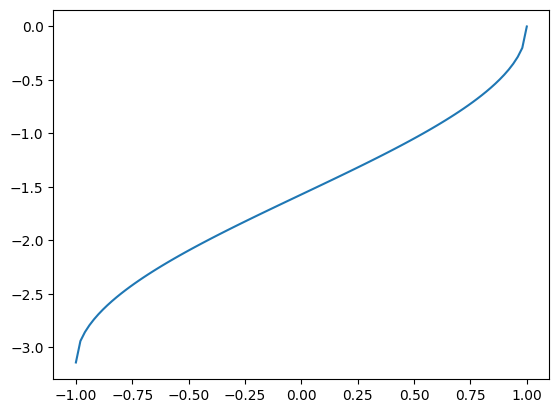

In [ ]:
plt.plot(torch.linspace(-10,10,1001),y.detach())

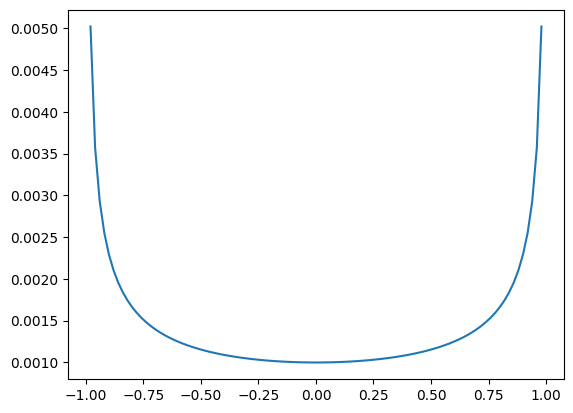

In [ ]:
plt.plot(torch.linspace(-10,10,1001),x.grad.detach())

In [ ]:
val_embeddings = []
model.eval()
with torch.no_grad():
    for images in tqdm(val_loader):
        images = {k: v.to(device) for k, v in images.items()}
        val_embeddings.append(model.get_image_features(**images))
pickle.dump(torch.cat(val_embeddings,dim=0).detach().cpu().numpy(),open("Val_emb.pkl",'wb'))

100%|██████████| 4930/4930 [10:53<00:00,  7.55it/s]


In [ ]:
import torch

In [ ]:
cp['vision.backbone.stages.3.blocks.0.mlp.fc2.weight'].shape

torch.Size([1024, 4096])

In [ ]:
cp = torch.load("counterfeit_multimodal/runs_e/tb/version_106/checkpoints/best-epoch=06-val_auroc=0.0000-v1.pth")

In [ ]:
import pandas as pd
import pickle
df = pd.read_csv("counterfeit_multimodal/data/train.csv")
import os

In [ ]:
df['text'].isna().sum()

np.int64(82137)

In [ ]:
r =pd.read_csv("ml_ozon_counterfeit_train.csv")
e = pd.read_csv("ml_ozon_counterfeit_test.csv")

In [ ]:
s = set(r['SellerID'].values).intersection(set(e['SellerID'].values))

In [ ]:
r.groupby("brand_name").count()['id'].sort_values()

brand_name
A.G.N.I              1
A-Mall               1
A&M AKS              1
A good choice.       1
A & N market         1
                  ... 
Levsha kaluga     3009
Sony              3053
OEM               4275
ProFDetali        4811
iQZiP             6084
Name: id, Length: 4066, dtype: int64

In [ ]:
a = e.loc[e['SellerID'].isin(s)]

In [ ]:
import pandas as pd
df = pd.read_csv("counterfeit_multimodal/data/test_m.csv")

In [ ]:
def remove_name(text):
    return text[:-text[::-1].index(">s/<")-5]

# Ремоколор

In [ ]:
df['text'] = df['text'].apply(remove_name)

In [ ]:
df['text'][0]

'NAN</s>Приветствую Мы собираем классные системные блоки с 2018 года Нам очень близка игровая культура и мы понимаем как не просто стоять на миде При сборке использовались современные комплектующие Комплектующие обязательно только новые Быстрые SSD M 2 и оперативная память DDR5 В сердце системного блока стоит легендарный AMD Ryzen а конфигуратор позволяет выбрать одну из топовых видеокарт Гарантия 12 месяцев Операционная система в комплекте Системный блок полностью настроен и готов к работе из коробки </s>LeBefane Системный блок AMD Ryzen 5 7500F RAM 64 ГБ SSD 1000 ГБ NVIDIA GeForce RTX 4070 SUPER 12 Гб Window 11 Pro белы'

In [ ]:
df.to_csv("counterfeit_multimodal/data/test_m_noname.csv")

In [ ]:
df.to_csv("counterfeit_multimodal/data/train_m_noname.csv")

In [ ]:
df['text'][0]

'MyPad </s>Камера MyPad для Xiaomi Mi 5X Xiaomi Mi A1 Задняя основная </s>Камера MyPad для Xiaomi Mi 5X Xiaomi Mi A1 Задняя основная'

In [ ]:
s = df['text'][0]

In [ ]:
print

'MyPad </s>Камера MyPad для Xiaomi Mi 5X Xiaomi Mi A1 Задняя основная </s>Камера MyPad для Xiaomi Mi 5X Xiaomi Mi A1 Задняя основная'

In [ ]:
import torch

In [ ]:
from transformers import AutoModel

In [ ]:
model, preprocess = clip.load("ViT-L/14", device=device)

In [ ]:
from multilingual_clip import pt_multilingual_clip
import transformers

texts = [
    'Three blind horses listening to Mozart.',
    'Älgen är skogens konung!',
    'Wie leben Eisbären in der Antarktis?',
    'Вы знали, что все белые медведи левши?'
]
model_name = 'M-CLIP/LABSE-Vit-L-14'

# Load Model & Tokenizer
model = pt_multilingual_clip.MultilingualCLIP.from_pretrained(model_name)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

c:\Users\ADMIN\Documents\codenrock\2055-fraud\venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--M-CLIP--LABSE-Vit-L-14. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

c:\Users\ADMIN\Documents\codenrock\2055-fraud\venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--sentence-transformers--LaBSE. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling b

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

In [ ]:
cp = torch.load("cps/7545-fused-0.75th.pth")

In [ ]:
cp

OrderedDict([('vision.projection.weight',
              tensor([[ 2.9231e-02, -3.8782e-03, -6.9024e-03,  ...,  1.7709e-02,
                       -3.8401e-03,  2.1606e-03],
                      [-2.2989e-02,  2.2243e-02,  3.4376e-05,  ...,  6.5533e-03,
                       -2.0109e-03,  5.4370e-03],
                      [-5.8592e-05,  2.1555e-02,  6.8828e-03,  ...,  1.0339e-03,
                        5.7715e-03,  3.1034e-02],
                      ...,
                      [-3.0859e-02, -1.7549e-02, -1.0257e-02,  ..., -1.1846e-02,
                        8.0327e-03, -2.3115e-02],
                      [ 7.4123e-03, -9.9509e-03,  2.3286e-02,  ...,  1.0705e-02,
                       -2.2430e-02, -4.5755e-02],
                      [-2.7997e-03,  2.1125e-04,  2.1557e-02,  ...,  1.8612e-02,
                        1.0890e-02,  1.2372e-02]], device='cuda:0')),
             ('vision.projection.bias',
              tensor([ 0.0078, -0.0278, -0.0544,  ...,  0.0056,  0.0162,  0.0143],
  

In [ ]:
e.shape

(22760, 44)

In [ ]:
a.shape

(14837, 44)

In [ ]:
os.path.exists(f"ml_ozon_сounterfeit_train_images/{df['image_path']}.png")

281       True
1128      True
1527      True
1805      True
2476      True
          ... 
176837    True
176844    True
176862    True
177170    True
177196    True
Name: image_path, Length: 672, dtype: bool

In [ ]:
if df['text'].isna()[3]:
    print(True)
else:
    print(False)

False


In [ ]:
a = pickle.load(open("counterfeit_multimodal/Test_emb_t_init.pkl","rb"))

In [ ]:
from torch.nn.functional import cosine_similarity
import torch

In [ ]:
cosine_similarity(torch.tensor(a[0]).view(1,-1),torch.tensor(a[-5]).view(1,-1))

tensor([1.0000])

In [ ]:
a[0]

array([-0.08751122,  0.03940569,  0.09572803, ...,  0.00910939,
       -0.07709296, -0.02793963], shape=(1024,), dtype=float32)

In [ ]:
import pandas as pd

In [ ]:
df_test = pd.read_csv("ml_ozon_counterfeit_test.csv")

In [ ]:
df_full = pd.read_csv("ml_ozon_counterfeit_train.csv")

In [ ]:
df_train = df_full.head(175000)

In [ ]:
df_val = df_full.tail(df_full.shape[0]-175000)

In [ ]:
df_test['CommercialTypeName4'].nunique()

440

In [ ]:
diff = set(list(df_val['SellerID'].values)).difference(df_train["SellerID"].values)

In [ ]:
ts = pd.read_csv("counterfeit_multimodal/data/test_ts.csv")

In [ ]:
len(diff)

1137

In [ ]:
df_test.loc[df_test['CommercialTypeName4'].isin(diff)]

,id,brand_name,description,name_rus,CommercialTypeName4,rating_1_count,rating_2_count,rating_3_count,rating_4_count,rating_5_count,...,ExemplarReturnedCountTotal30,ExemplarReturnedCountTotal90,ExemplarReturnedValueTotal7,ExemplarReturnedValueTotal30,ExemplarReturnedValueTotal90,ItemVarietyCount,ItemAvailableCount,seller_time_alive,ItemID,SellerID
420,251314,Dyson,Насадка-концентратор для укладки волос к фенам...,Насадка-концентратор для фена Dyson Supersonic...,Насадки для фена Dyson,1.0,0.0,0.0,0.0,3.0,...,16.0,66.0,1050.041755,1163.254218,1348.916381,1.0,1.0,393.0,123497,4065
981,171146,ROYAL CLIMA,● Высокий напор внутреннего блока (до 160Па)<b...,Сплит-система канального типа ROYAL CLIMA сери...,Кондиционер канальный,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.000000,0.000000,0.000000,17.0,17.0,40.0,83842,1323
2031,344921,Ballu,"Мобильный кондиционер BPHS-11H мощностью 3,06 ...",Мобильный кондиционер Ballu BPHS-11H,Охладитель воздуха,NaN,NaN,NaN,NaN,NaN,...,25.0,69.0,1091.339629,1299.543014,1382.648489,16.0,16.0,728.0,169731,2392
3543,171924,Canon,Настольный копир Canon imageRUNNER 2206 (3030C...,Копир Canon imageRUNNER 2206 (3030C001) лазерн...,Копировальный аппарат,NaN,NaN,NaN,NaN,NaN,...,102.0,277.0,1046.296093,1259.793165,1386.257219,425.0,425.0,997.0,84218,576
4580,204454,Aceline,"Когда на улице жаркие дни, хочется найти прохл...","Охладитель воздуха бытовой, настольный, 7Вт",Охладитель воздуха,NaN,NaN,NaN,NaN,NaN,...,52.0,170.0,910.428521,1153.491043,1297.004665,10.0,10.0,1217.0,100078,1290
5001,52986,NORDFROST,Общие данные:\nРазмеры:\nвысота: 83.5 см\nшири...,Морозильный ларь NORDFROST CF 200,Морозильный ларь,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,241.0,26446,2938
5406,76128,Bosch,Офисный брошюровщик для переплета пластиковой ...,Брошюровщик / переплетчик Office Kit B2121 на ...,Брошюровщик,NaN,NaN,NaN,NaN,NaN,...,102.0,277.0,1046.283732,1259.801491,1386.249484,425.0,425.0,997.0,37919,576
5622,12254,ROYAL CLIMA,● Функция защиты от простуды в режиме охлажден...,Сплит-система канального типа ROYAL CLIMA сери...,Кондиционер канальный,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,0.000000,0.000000,3.0,3.0,44.0,6170,1323
5901,442979,NaN,Наушники TF20 с сенсорным экраном представляют...,"Новая Bluetooth-гарнитура TF20, внешний аккуму...",Зарядное устройство для аккумуляторов,0.0,0.0,0.0,0.0,1.0,...,9.0,16.0,859.697755,935.419618,1007.144390,2.0,2.0,207.0,215506,6234
6372,184948,NaN,Привод BD-ROM&DVD RAM&DVD±R/RW&CDRW Samsung SH...,плеер BD-ROM Samsung SH-B123L SATA,Blu-ray плеер,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,1241.0,90539,7635


In [ ]:
from PIL import Image
import numpy as np

In [ ]:
np.array(Image.open("dummy.png").convert("RGB")).shape

(720, 1280, 3)

In [ ]:
test_embeddings = []
model.eval()
with torch.no_grad():
    for images in tqdm(inference_loader):
        images = {k: v.to(device) for k, v in images.items()}
        test_embeddings.append(model.get_image_features(**images))
pickle.dump(torch.cat(test_embeddings,dim=0).detach().cpu().numpy(),open("Test_emb.pkl",'wb'))

100%|██████████| 5690/5690 [14:01<00:00,  6.76it/s]


In [ ]:
CP = "counterfeit_multimodal/runs/tb/version_2/checkpoints/best-epoch=00-val_f1=0.0000.pth"

In [ ]:
import torch

OrderedDict([('vision.model.stem.0.weight',
              tensor([[[[ 0.0165,  0.0851, -0.0224, -0.0590],
                        [ 0.0611,  0.0956, -0.0854, -0.0282],
                        [-0.0055, -0.0121, -0.0009,  0.0622],
                        [-0.0851, -0.0814,  0.0280,  0.0301]],
              
                       [[ 0.0252,  0.0947, -0.0346, -0.0474],
                        [ 0.0536,  0.0631, -0.1181, -0.0717],
                        [-0.0303, -0.0313, -0.0283,  0.0851],
                        [-0.0547, -0.0468,  0.0677,  0.0973]],
              
                       [[ 0.0178,  0.0545, -0.0106, -0.0212],
                        [ 0.0135,  0.0208, -0.0958, -0.0552],
                        [-0.0454, -0.0564, -0.0216,  0.0441],
                        [-0.0233, -0.0159,  0.0750,  0.1020]]],
              
              
                      [[[-0.0488, -0.0285, -0.0102, -0.0290],
                        [-0.0222,  0.0076,  0.0703,  0.0078],
                        

In [ ]:
pickle.load(open("Train_emb.pkl",'rb'))

array([[ 0.4436 ,  0.5977 , -0.06384, ...,  0.4236 , -0.7275 , -0.3447 ],
       [ 0.459  ,  0.3281 ,  0.08887, ..., -0.1586 , -0.51   , -0.3594 ],
       [ 0.0421 ,  0.6694 ,  0.0778 , ..., -0.241  , -1.121  , -0.0636 ],
       ...,
       [ 0.6123 ,  0.683  ,  0.02562, ...,  0.3499 , -0.7935 , -0.125  ],
       [ 0.5596 ,  0.574  ,  0.3923 , ..., -0.1326 , -0.2708 , -0.5327 ],
       [ 0.4558 ,  0.5947 ,  0.2244 , ...,  0.3757 , -0.2488 , -0.3518 ]],
      shape=(177478, 512), dtype=float16)

In [ ]:
torch.cat(train_embeddings,dim=0).shape

torch.Size([177478, 512])

In [ ]:
torch.load

In [ ]:
import unicodedata
from bs4 import BeautifulSoup
import re

def is_cyrillic(char):
    return 'CYRILLIC' in unicodedata.name(char)

def is_latin(char):
    return 'LATIN' in unicodedata.name(char)


LOOKALIKE_MAP = {
    'a': 'а',  # латинская 'a' → кириллическая 'а'
    'c': 'с',
    'e': 'е',
    'o': 'о',
    'p': 'р',
    'x': 'х',
    'y': 'у',
    'A': 'А',
    'B': 'В',
    'E': 'Е',
    'K': 'К',
    'M': 'М',
    'H': 'Н',
    'O': 'О',
    'P': 'Р',
    'C': 'С',
    'T': 'Т',
    'Y': 'У',
    'X': 'Х',
    'n': 'п',
    'u':'и',
    'k':'к',
}

LOOKALIKE_INVERSED_MAP = {v: k for k, v in LOOKALIKE_MAP.items()}



def fix_mixed_word(word):

    alphabet,mixed = check_alphabet(word)

    if mixed:
        new_chars = []
        if alphabet == "cyrillic":
            map = LOOKALIKE_MAP
            checker = is_latin
        else:
            map = LOOKALIKE_INVERSED_MAP
            checker = is_cyrillic
        for ch in word:
            if checker(ch) and ch in map:
                new_chars.append(map[ch])
            else:
                new_chars.append(ch)
        word = ''.join(new_chars)
    return word, mixed



def check_alphabet(word):
    cyrillic_count = 0
    latin_count = 0
    alphabet = None
    mixed = False
    for ch in word:
        if is_cyrillic(ch):
            cyrillic_count+=1
            if not ch in LOOKALIKE_MAP:
                alphabet = "cyrillic"
        else:
            latin_count += 1
            if not ch in LOOKALIKE_INVERSED_MAP:
                alphabet = "latin"
    if alphabet is None:
        alphabet = "cyrillic" if cyrillic_count > latin_count else "latin"
    if cyrillic_count > 0 and latin_count > 0:
        mixed = True
    print(alphabet)
    return alphabet, mixed



def clean_text(text):
    soup = BeautifulSoup(text)
    cleaned = soup.get_text()
    normalized = unicodedata.normalize("NFC",cleaned)
    normalized = re.sub(r'[^a-zA-Zа-яА-Я0-9\s]', '', normalized)
    words = normalized.split()
    is_mixed = False
    replaced_words = []
    
    for word in words:
        w,mixed = fix_mixed_word(word)
        replaced_words.append(w)
        if mixed:
            is_mixed = mixed
    cleaned_text = " ".join(replaced_words).lower()

    
    cleaned_text = re.sub("\s+"," ",cleaned_text)
    # replaced,is_mixed = fix_mixed_word(cleaned_text) ## 
    return cleaned_text,is_mixed

In [ ]:
import timm
model = timm.create_model("timm/convnext_large.fb_in22k_ft_in1k_384", pretrained=True, num_classes=0, global_pool='avg')

In [ ]:
from transformers import AutoModel
model = AutoModel.from_pretrained("DeepPavlov/xlm-roberta-large-en-ru")

In [ ]:
import torch

In [ ]:
import pickle

In [ ]:
pickle.load(open("counterfeit_multimodal/runs/tb/version_0/checkpoints/best-epoch=02-val_f1=0.0000-v1.pth","rb"))

EOFError: Ran out of input

In [ ]:
from transformers import convnext

In [ ]:
import pandas as pd

In [ ]:
import re

In [ ]:
df = pd.read_csv("submit.csv")

In [ ]:
df['id'] = df['id'].apply(lambda x: re.sub(r'[^0-9]','',x)).astype(int)

In [ ]:
df.to_csv("submit.csv",index=False)

In [ ]:
import torch

In [ ]:
torch.cuda.is_available()

True

In [ ]:
from transformers import ViTModel

In [ ]:
print(torch.version.cuda)

None


In [ ]:
import torch

In [ ]:
torch.__version__

'2.8.0+cu129'

In [ ]:
pip install torch

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
